# Assessment of spatial and temporal stability of tributary-specific

otolith trace element signatures

Brown Trout (*Salmo trutta*) in the Lower Clutha River Catchment

Olivier V. Raven [](https://orcid.org/0009-0008-6184-6831) (University of Otago, Wageningen University & Research)  
J.E.M. Couper (Fish & Game Otago)  
Hellen Trotter (Fish & Game Otago)  
Malcom R. Reid [](https://orcid.org/0000-0002-4129-0214) (University of Otago)  
R. Svirgsden (University of Tartu)  
M. Rohtla [](https://orcid.org/0000-0002-7587-5552) (University of Tartu)  
G.P. Closs [](https://orcid.org/0000-0003-4550-6024) (University of Otago)  
June 3, 2025

Otolith trace element analysis is a powerful tool for studying fish migration between juvenile and adult habitats. To track catchment-scale migration, trace element signatures in juvenile otoliths are compared to the otolith natal region of adults, with the aim of matching adults to their natal habitat. However, the stability of signatures in natal habitat over time, crucial for this method to work across generations, has rarely been tested. To evaluate spatiotemporal stability of natal stream trace element signatures in otoliths, a four-year study in New Zealand’s lower Clutha River/Mata-Au was executed. 602 brown trout juveniles from 20 tributaries were sampled and trace element analysis was performed, enabling comparisons of the signatures within each stream over time. The findings suggest the signatures of the elements Mn, Sr, and Ba incorporated into otoliths are generally stable within each catchment over four-years. This means that, if tracking adult trout back to their natal stream it is not necessary to analyse juvenile otoliths from each year. Spatial variability of Mn, Sr and Ba was tested by using Random Forest and Linear Discriminant Analysis models, which assigned juvenile trout to the correct stream in 61% and 52% cases, respectively. Grouping the sites using Nearest-Neighbour Cluster Analysis resulted in 93% accuracy for both models. Collection of juveniles from key spawning streams across 2-3 years should be sufficient to establish reference signatures for each tributary that will facilitate tracking of adult migration over several years.

In [ ]:
if (!file.exists("data/derived/inline_values.rds")) {
  stop("inline_values.rds not found. Please render analysis.qmd first.")
}

vals <- readRDS("data/derived/inline_values.rds")
accuracy_lda <- vals$accuracy_lda
accuracy_rf <- vals$accuracy_rf
p_waiwera_mn_2022_2021 <- vals$p_waiwera_mn_2022_2021
p_mn_2015_2022 <- vals$p_mn_2015_2022
p_ba_2015_2022 <- vals$p_ba_2015_2022
p_ba_2015_2021 <- vals$p_ba_2015_2021
p_ba_2023_2021 <- vals$p_ba_2023_2021
p_ba_2023_2022 <- vals$p_ba_2023_2022
accuracy_Svirgsden_rf <- vals$accuracy_Svirgsden_rf
accuracy_Svirgsden_lda <- vals$accuracy_Svirgsden_lda
accuracy_lda_nnca <- vals$accuracy_lda_nnca
accuracy_rf_nnca <- vals$accuracy_rf_nnca

# Introduction

Migration is an important aspect of the life cycle for many fish species. Therefore, understanding fish migration patterns and behaviour is crucial for sustainable management of fish populations ([Carlson et al., 2016](#ref-Carlson2016)). Brown trout (*Salmo trutta L.*) can migrate extensively over their lifetime ([Klemetsen et al., 2003](#ref-Klemetsen2003)), which is typical for many salmonid species. Brown trout exhibit variable life history strategies including residency, potadromy, and anadromy ([Elliott, 1994](#ref-Elliott1994); [Jonsson & Jonsson, 2011](#ref-Jonsson2011)). Migration is important for some trout populations which access productive lower river reaches, estuaries or the sea allowing enhanced growth ([Thorstad et al., 2012](#ref-Thorstad2012)). Spawning occurs mostly in small tributaries where juvenile trout remain typically for six months to two years prior to migrating to the larger systems where they continue growing ([Ferguson et al., 2019](#ref-Ferguson2019); [Klemetsen et al., 2003](#ref-Klemetsen2003)).

Otolith chemistry offers a powerful method for reconstructing environmental history and inferring connectivity between juvenile and adult habitats ([Campana, 1999](#ref-Campana1999)). The trace element composition of otoliths, deposited in chronological layers, reflects environmental conditions experienced during a fish’s life and has been widely applied to track movement patterns ([Reis-Santos et al., 2022](#ref-ReisSantos2022)). By comparing the juvenile section of adult otoliths with elemental signatures from known juvenile reference samples, it is possible to identify natal origins and reconstruct migration pathways ([Carlson et al., 2016](#ref-Carlson2016); [Elsdon et al., 2008](#ref-Elsdon2008); [Jones & Chen, 2003](#ref-Jones2003); [Olley et al., 2011](#ref-Olley2011); [Reis-Santos et al., 2013](#ref-ReisSantos2013)). This approach requires knowledge of fish age and access to temporally and spatially representative juvenile otolith data. Due to the scarcity of long-term reference datasets, many studies assume limited temporal variation in trace element signatures, although this assumption should be ideally warranted for further investigation ([Loher et al., 2021](#ref-Loher2021)). If temporal variability is minimal, juvenile otolith signatures can be used to generate spatial maps that improve our understanding of trout migration and habitat use ([Olley et al., 2011](#ref-Olley2011)).

Most studies that have investigated spatiotemporal variability of otolith chemistry have been implemented in marine or estuarine systems. Interannual and intra-annual variation has been found in these systems for various fish species ([Gillanders, 2002](#ref-Gillanders2002); [Hamer et al., 2003](#ref-Hamer2003); [Milton et al., 1997](#ref-Milton1997); [Ruttenberg et al., 2008](#ref-Ruttenberg2008); [Swearer et al., 2003](#ref-Swearer2003)). Clarke et al. ([2009](#ref-Clarke2009)) show significant interannual variation in juvenile *Menidia menidia* between 2003 and 2004. Reis-Santos et al. ([2012](#ref-ReisSantos2012)) found temporal differences between 2006 and 2009 in estuary-dwelling flounder (*Platichthys flesus*) and European sea bass (*Dicentrarchus labrax*). For the European sea bass Reis-Santos et al. ([2018](#ref-ReisSantos2018)) also found temporal differences within 2009. Similarly, Schaffler et al. ([2014](#ref-Schaffler2014)) found temporal variation between two years in Atlantic Menhaden (*Brevoortia tyrannus*). Only Aschenbrenner et al. ([2016](#ref-Aschenbrenner2016)) found stable element ratios in estuaries over three consecutive years in Brazilian snapper (*Lutjanus alexandrei*). Elsdon & Gillanders ([2006](#ref-Elsdon2006)) investigated estuarine water temporal variance, considering temperature, salinity, and concentrations of Sr, Ca, Ba, and Mn over various time scales, from seasons to tidal cycles and found differences which could affect element signature.

In contrast, riverine environments tend to exhibit lower temporal variability compared to estuaries, which suggests that otolith chemistry in riverine fish may show less variation over time ([Swearer et al., 2003](#ref-Swearer2003)). Thorrold et al. ([1998](#ref-Thorrold1998)) observed minimal temporal variance in otolith chemistry between months for juvenile American shad (*Alosa sapidissima*) in rivers. In trout, Matetski et al. ([2021](#ref-Matetski2021)) showed intra-annual variation, with Sr concentrations higher in summer compared to winter, while Ba concentrations showed the opposite pattern. Martin et al. ([2013](#ref-Martin2013)) noted interannual differences in otolith elemental composition among rivers for Atlantic salmon (*Salmo salar*) but emphasized that this variability was minor compared to geographic variability. This is also the case for long-whiskered catfish (*Sperata aor*) as shown by Nazir & Khan ([2019](#ref-Nazir2019)). Despite these studies, the temporal stability of trace element signatures has not been extensively investigated in river systems. Therefore, this study aims to investigate the temporal variability of trace element signatures in juvenile brown trout, exploring whether these signatures are consistent and can be used for inter-generational tracking of the natal streams of adult brown trout in the lower Clutha catchment.

To address this question, the otoliths of 608 juvenile brown trout were collected from 20 different tributaries over four years. By comparing trace element signatures within each stream across time, the spatiotemporal stability of natal stream signatures was evaluated. The study examined thirteen trace elements to determine whether their stability was greater across space or time. To further assess classification accuracy, both Random Forest (RF) and Linear Discriminant Analysis (LDA) models were applied.

# Methods

## Research location

The Clutha River/ Mata-Au is the longest river in the South Island of New Zealand/ Aotearoa with a catchment area of 21,960 km2, and a total length of 338 km. Two hydroelectric power stations, the Clyde Dam, and the Roxburgh Dam divide the river catchment into sections. The main land cover in the catchment is high-producing exotic grasslands for agriculture ([Otago Regional Council, 2023](#ref-ORC2023)). Introduced in the late 1860s to the Clutha River catchment, brown trout life cycles are similar to brown trout in their native range, with spawning occurring in the gravel beds of smaller tributaries during autumn, and fry emerging in spring. As the juvenile fish grow, they may migrate downstream to larger systems when food availability becomes critical, and the risk of migrating becomes more favourable than staying in the natal stream ([Jonsson & Jonsson, 2011](#ref-Jonsson2011)). Migration downstream to the sea may occur before returning to tributary streams to reproduce ([Ferguson et al., 2019](#ref-Ferguson2019)). For this research, otoliths were collected from juvenile brown trout caught in the tributary streams of the lower Clutha River (<a href="#fig-sites-map" class="quarto-xref">Figure 1</a>). The lower Clutha River is located downstream of the Roxburgh Dam. The main tributary of the lower Clutha River is the Pomahaka River. The Pomahaka River is 98 km long and has a catchment area of 2,060 km2. A prominent tributary of the Pomahaka River is the Waipahi River.

<figure id="fig-sites-map">
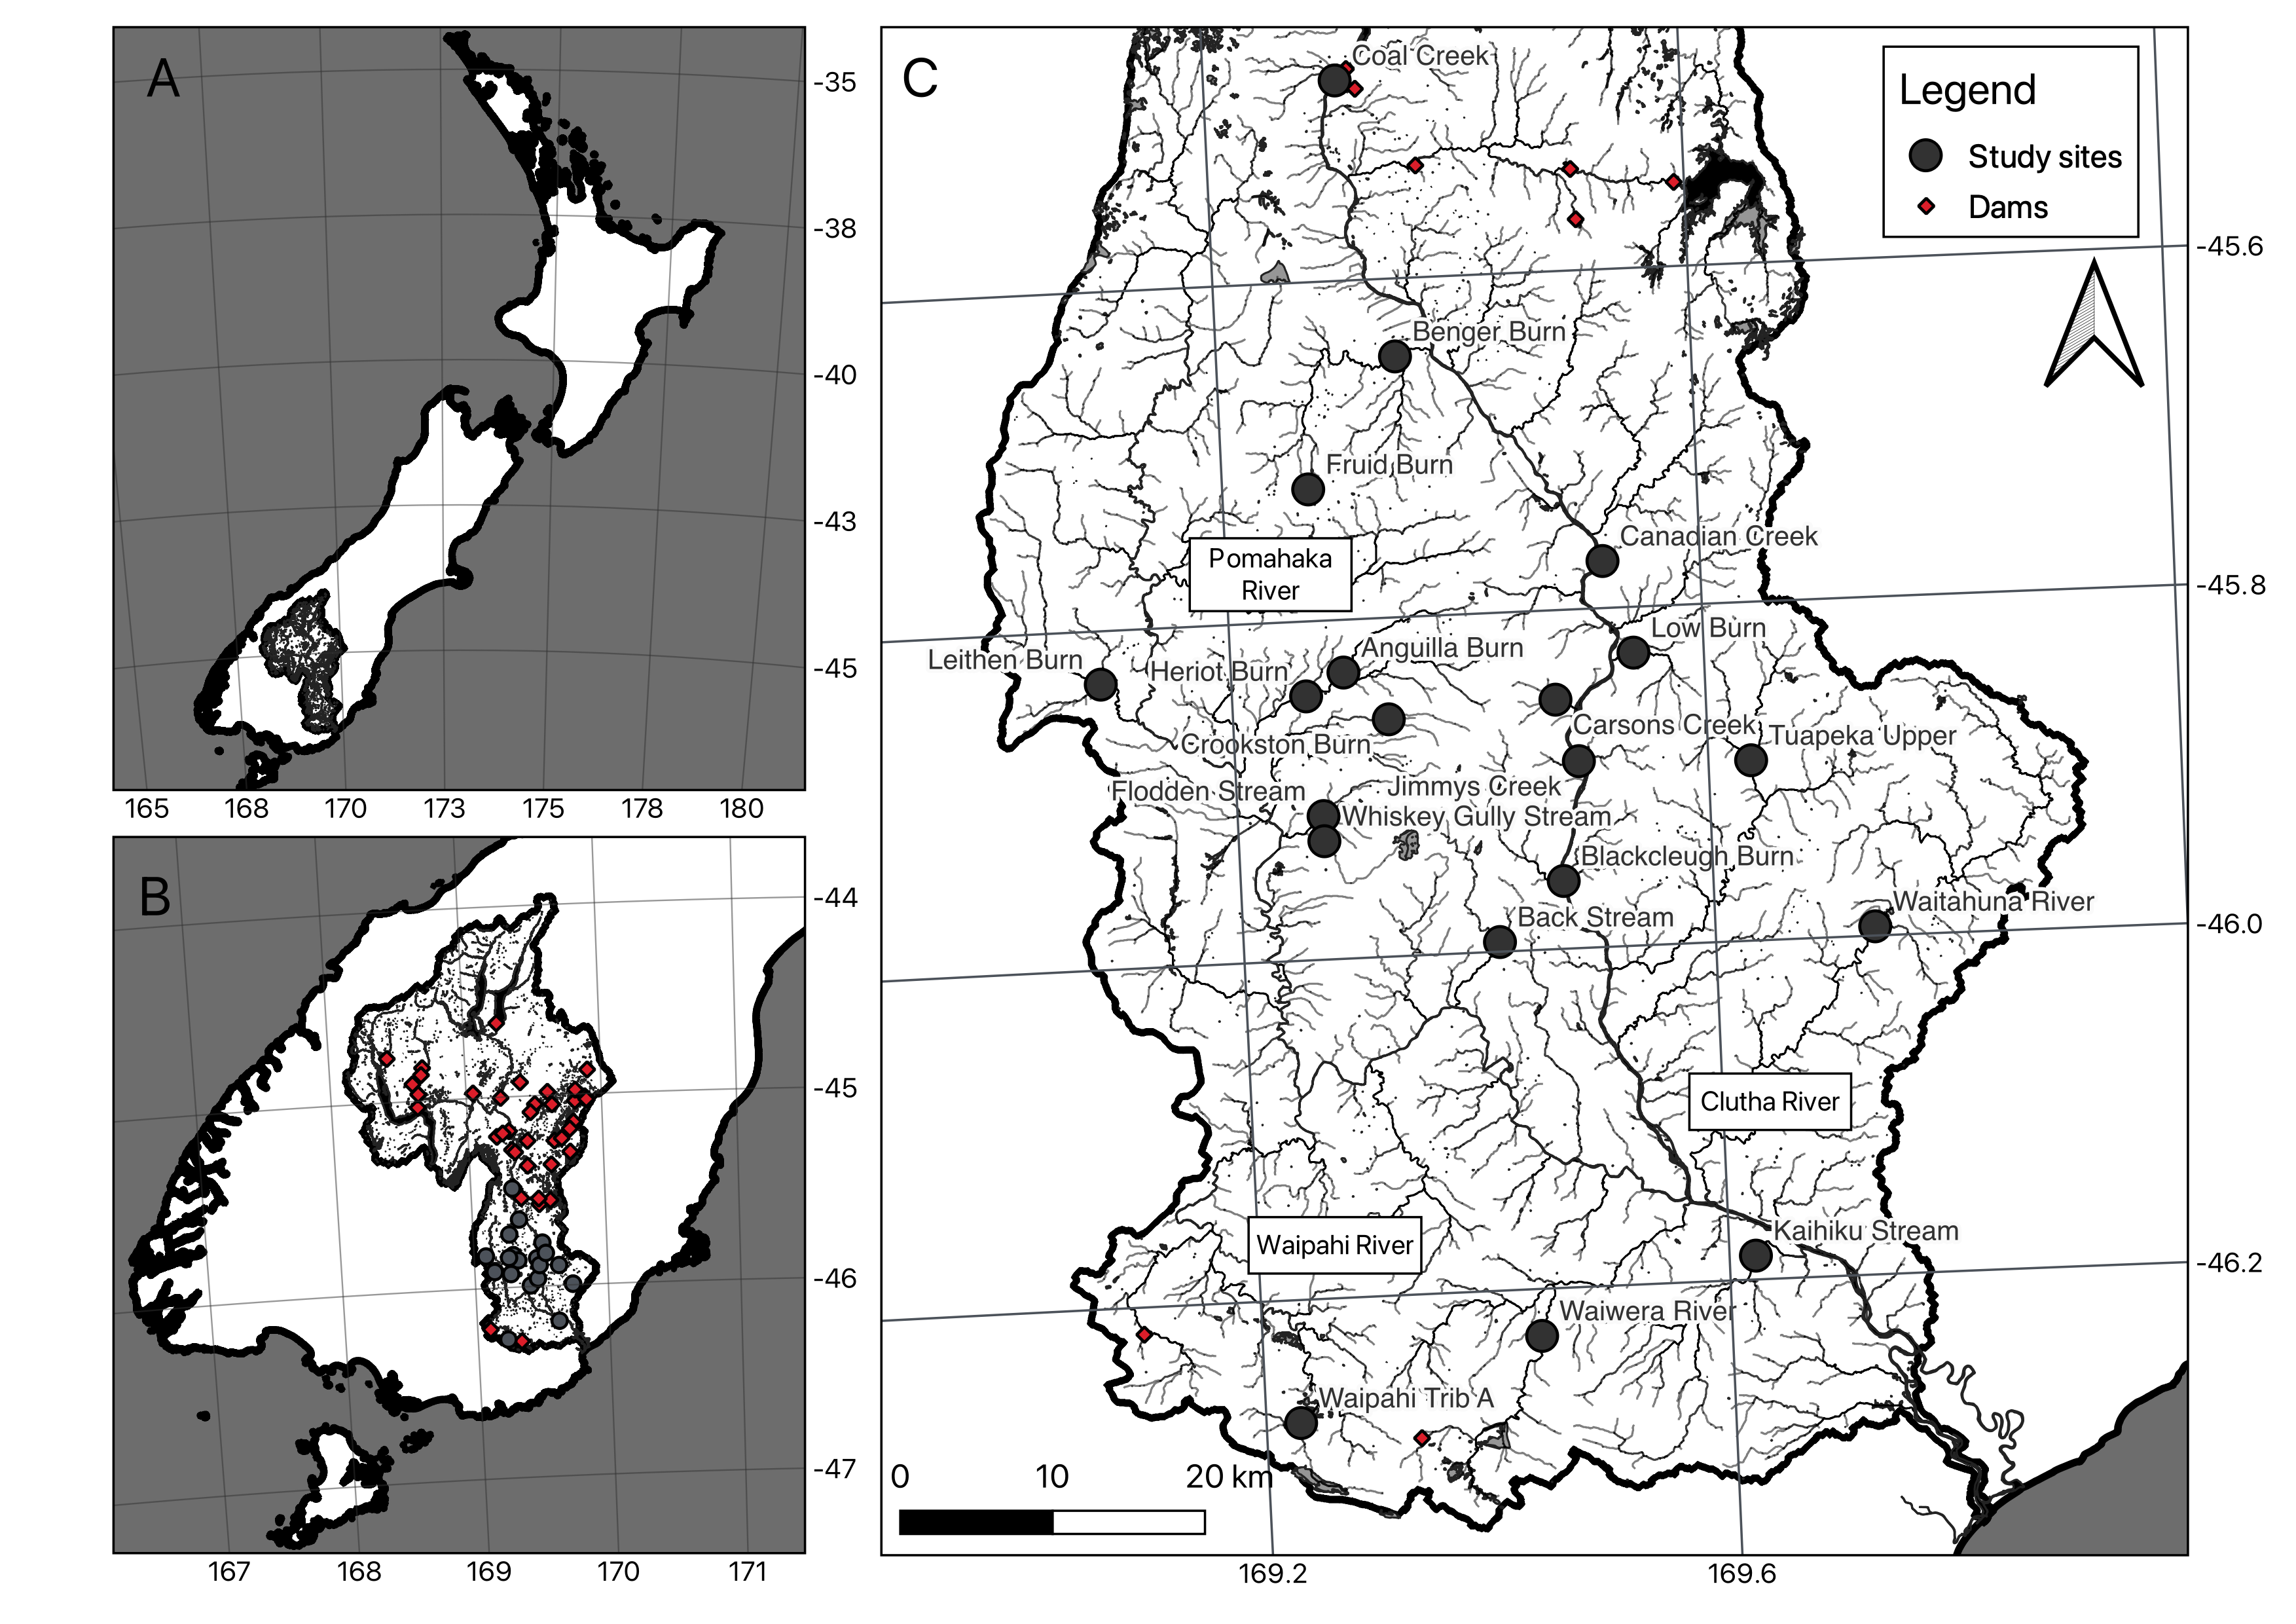
<figcaption>Figure 1: A) Map of New Zealand showing the location of the Clutha River catchment on the South Island. B) Map of the Clutha River catchment area with the dams. C) map of the lower Clutha River with the study sites where the juvenile brown trout were caught. After: <span class="citation" data-cites="MFE2010">Ministry for the Environment (<a href="#ref-MFE2010" role="doc-biblioref">2010</a>)</span> and <span class="citation" data-cites="Linz2025">Land Information New Zealand (LINZ) (<a href="#ref-Linz2025" role="doc-biblioref">2025</a>)</span>. This map was created using QGIS software by Esri.</figcaption>
</figure>

## Sampling design

In the lower Clutha River catchment, 20 smaller tributaries were selected as sampling sites (<a href="#fig-sites-map" class="quarto-xref">Figure 1</a>). These sites were chosen from an initial pool of 34 locations based on the consistent presence of juvenile trout populations across multiple years, allowing for reliable sampling. The final 20 sites are distributed across the lower catchment to provide broad spatial coverage of the system. Approximately 10 juvenile trout were collected per site per year, enabling the detection of intra-site variation in fish size and elemental composition. Sites were selected based on several key criteria: they are located downstream of migratory barriers such as dams, they are accessible via public roads, and they are recognized trout spawning areas. Because these tributaries function as spawning and nursery habitats, the juvenile trout found in these waters are likely to have spent their entire early life stages within the same stream. Migration to larger, more favourable habitats typically occurs after the juvenile stage ([Klemetsen et al., 2003](#ref-Klemetsen2003)), which supports the assumption of site fidelity required for elemental origin analysis. Sampling was conducted annually from 2020 to 2023, although not all sites were successfully fished each year due to environmental or logistical constraints (<a href="#fig-sites-info" class="quarto-xref">Figure 7</a>). Sampling typically took place between January and March to reduce seasonal variability, except for the Waiwera River, Waitahuna River, and Fruid Burn sites in 2021, which were sampled in August and September.

## Otolith collection and preparation

Juvenile (parr) brown trout were collected from each site by electrofishing and euthanized using AQUI-S Aquatic Anaesthetic. For each fish, weight (g) and total length (mm) were measured. Fish with lengths less than 120 mm were utilized to limit the variability in length and age in any one year ([Hayes, 1988](#ref-Hayes1988); [Jellyman et al., 2017](#ref-Jellyman2017); [Kristensen & Closs, 2008](#ref-Kristensen2008)). The weight (g) and total length (mm) ranged from 0.4-24.8 g with a mean (±SEM) of 6.7 g (±0.3) and 34-119 mm mean (±SEM) of 79.2 mm (±1.0). The sagittae otoliths from each fish were removed and stored. If possible, otoliths from ten fish from each site for each year were analysed as replicates. In total 608 sagittae otoliths were extracted from the fish. The otoliths were placed with their distal surface (surface without the sulcal groove) up on microscope slides with double-sided tape, with 152 otoliths per slide. If possible, the left otolith was used, but if this was not possible due to it being missing or broken, the right otolith was used (see [Campana et al., 2000](#ref-Campana2000)).

## Otolith microchemical analysis

Otolith trace element composition was determined using laser ablation inductively coupled plasma mass spectrometry (LA-ICP-MS) ([Jones & Chen, 2003](#ref-Jones2003)). The trace element concentration data using the following isotopes, 7Li, 23Na, 24Mg, 27Al, 31P, 39K, 43Ca, 55Mn, 57Fe, 65Cu, 66Zn, 85Rb, 88Sr, and 138Ba were collected using an Agilent 7900 ICP-MS coupled to a ASI RESOlution M-50 laser ablation system powered by a Coherent 193nm ArF excimer laser located in the Centre for Trace Element Analysis at the University of Otago, Dunedin, New Zealand.

Each otolith was drill ablated on its proximal side in the middle of the otolith. The laser was set with a diameter of 75 µm at 10 Hz and an on-sample fluence of 2.5 Jcm-2. The total ablation of each otolith lasted 40 sec. As a result, the ablated material leaves a hole of unmeasured depth but probably deeper than 500 µm ([Jones & Chen, 2003](#ref-Jones2003)). The ablated material likely represents growth increments from the early life stages, providing insights into their environmental history during this period. The real depth of the ablation is not known but, as juvenile brown trout typically stay in their natal water during their first year of life ([Klemetsen et al., 2003](#ref-Klemetsen2003)), there should be no major difference in the concentration of trace elements from the outermost layer down to the core of their otoliths, assuming natal stream trace element concentrations are relatively stable through the year.

Reference materials NIST610, NIST612 and MACS3 were ablated before and after batches of 8 otoliths to check for drift in the equipment. NIST610 was utilized for external calibration, with 43Ca served as the internal standard to account for differences in mass ablation yield ([Eggins et al., 2003](#ref-Eggins2003)). All element intensities were corrected for background count rates by subtracting the mean values measured with the laser off, as described in Eggins et al. ([2003](#ref-Eggins2003)). The data collected from the LA-ICP-MS was first analysed using IOLITE (Version 3.71) run on Igor Pro 7 (Version 7.08) ([Paton et al., 2011](#ref-Paton2011)). The LODs (Limits Of Detection) results for each element, were compared to the LODs reported by IOLITE and checked if they were below detection limits. This was only the case for copper. Elements below these values were still used to compare the means of each element ratio across different sites and years but were not used for further analysis. To eliminate any contamination, the initial 5 seconds and final 2 seconds of the ablation process were considered as pre- and post-ablation for each otolith. From the remaining ablation (33 sec), the mean of the thirteen element-to-calcium (Ca) ratios were calculated to g/g. In R (Version 4.3.0) ([R Core Team, 2023](#ref-rcoreteam2023)) this mass-based concentration was converted to a molar ratio to calcium (mmol/mol) after which data analysis was performed.

## Statistical analysis

Data from six vateritic otoliths were discarded before the statistical analysis, as only ablations with stable Ca signals and otoliths without vaterite were used to avoid any contaminated otoliths. To test the element concentrations for temporal stability and spatial variability MANOVA’s were executed. For a complete overview, all mean element values are visualised in boxplots. To test for intra-annual variation the three sites that were fished in August and September of 2021, ANOVA’s were performed to test for temporal stability within these sites.

To assess whether the spatial variation in selected trace element signatures could serve as a predictive factor for site of origin, we employed two distinct modelling approaches. First, a Random Forest (RF) model ([Mercier et al., 2011](#ref-Mercier2011)) was implemented with 400 decision trees using the “randomForest” package in R ([Liaw & Wiener, 2002](#ref-Liaw2002)). Second, a Linear Discriminant Analysis (LDA) model ([Olley et al., 2011](#ref-Olley2011)) was constructed using the “MASS” package in R ([Venables & Ripley, 2002](#ref-Venables2002)). For the LDA, the selected elements were combined across all years and sites. Prior to analysis, data were checked for multivariate normality and homogeneity of variance-covariance matrices to meet LDA assumptions; transformations were applied to elements where necessary to improve adherence to these assumptions. Model accuracy was evaluated using a leave-one-out cross-validation approach, wherein each signature was tested against all others.

The results were visualised in confusion matrixes displaying the predicted and actual sites of both models. After, the entire dataset was used to assess the performance of the LDA model, the results were visualized in a scatterplot of LD1 versus LD2. These approaches were possible due to the consistency of the reference materials, NIST612 and MACS3 (<a href="#fig-reference-material" class="quarto-xref">Figure 8</a>).

The distribution of the trace element signatures for each site in relation to each other was tested by Nearest-Neighbour Cluster Analysis (NNCA). The mean of the three spatially variable selected elements was used for each site (see results element selection). The output of this analysis show the relationship between the sites and the clusters that they belong to. To determine the optimal number of clusters, a Silhouette Index was calculated for different values of k (ranging from 2 to 19), and the number of clusters that maximized the silhouette score was selected. The accuracy of the clusters was further tested using RF and LDA models, and confusion matrixes and scatterplots were generated to evaluate the classification performance.

Additional otolith signatures were obtained from Svirgsden et al. ([2018](#ref-Svirgsden2018)) to extend the temporal scale of the analysis. In that study, 39 juvenile brown trout from four tributaries of the Waipahi River were analysed in March 2015. One of the sampling locations corresponded to the Waipahi Trib A site used in the current study, while the other three were within a 10 km radius. The study measured Mg, Mn, Sr, Ba, in the same way. In this present research, Mn, Sr, and Ba to Ca ratios from Svirgsden et al. ([2018](#ref-Svirgsden2018)) were incorporated to assess long-term variability in otolith geochemistry. Statistical differences across years at the Waipahi Trib A site were tested using MANOVA and ANOVA. Additionally, the 2015 dataset was integrated into the RF and LDA models alongside data from 2020–2023, allowing for a broader temporal comparison.

# Results

## Element selection

Elements selected for this study needed to be temporally stable and spatially variable. MANOVA results showed that Mn, Sr, and Ba were statistically different among sites but not across years (<a href="#tbl-element-selection-static" class="quarto-xref">Table 1</a>, <a href="#fig-main-elements" class="quarto-xref">Figure 2</a>), meeting the selection criteria. In contrast, Li, Na, Mg, Al, P, K, Fe, Cu, Zn, and Rb either showed no significant spatial variation or exhibited significant temporal variation (<a href="#tbl-element-selection-static" class="quarto-xref">Table 1</a>, <a href="#fig-other-elements" class="quarto-xref">Figure 9</a>), making them unsuitable. Additionally, Al, K, Cu, and Rb showed high relative standard deviation (RSD) values in the reference material MACS-3, indicating poor analytical precision (<a href="#fig-reference-material" class="quarto-xref">Figure 8</a>). As a result, only Mn, Sr, and Ba were selected for further analysis.

``` python
element_selection_display |>
  dplyr::mutate(
    `Spatial Variability` = ifelse(`Spatial Variability`, "Yes", "No"),
    `Temporal Stability` = ifelse(`Temporal Stability`, "Yes", "No")
  ) |>
  knitr::kable()
```

| Element | F-value (Site) | p-value (Site) | F-value (Year) | p-value (Year) | Spatial Variability | Temporal Stability | Classification |
|:------|---------:|-------:|--------:|-------:|:---------|:-------|:-------------|
| Li⁷ | 8.1182464 | 0.0000000 | 13.8239985 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| Na²³ | 3.5582822 | 0.0000009 | 85.3999340 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| Mg²⁴ | 0.7936608 | 0.7159571 | 10.3274679 | 0.0000020 | No | No | No clear effect |
| Al²⁷ | 1.4529399 | 0.1141095 | 2.5116387 | 0.0750397 | No | Yes | Temporally stable, NOT spatially variable |
| P³¹ | 3.5794384 | 0.0000009 | 23.4968634 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| K³⁹ | 4.8398620 | 0.0000000 | 48.2471412 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| Mn⁵⁵ | 31.5106270 | 0.0000000 | 2.0809712 | 0.1100530 | Yes | Yes | Spatially variable & temporally stable |
| Fe⁵⁷ | 7.8072613 | 0.0000000 | 32.8983095 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| Cu⁶⁵ | 1.1221396 | 0.3505214 | 22.0018920 | 0.0000000 | No | No | No clear effect |
| Zn⁶⁶ | 2.2680293 | 0.0021902 | 3.9891065 | 0.0113918 | Yes | No | Spatially variable, NOT temporally stable |
| Rb⁸⁵ | 34.4225136 | 0.0000000 | 26.7456006 | 0.0000000 | Yes | No | Spatially variable, NOT temporally stable |
| Sr⁸⁸ | 118.8171174 | 0.0000000 | 2.4300983 | 0.0759794 | Yes | Yes | Spatially variable & temporally stable |
| Ba¹³⁸ | 77.7910301 | 0.0000000 | 0.9060693 | 0.4378081 | Yes | Yes | Spatially variable & temporally stable |

Table 1: Output of MANOVA’s testing the mean of the thirteen trace elements between sites and year separately. The green colour indicating spatial variable but temporal stable.

## Temporal stability

The elements Mn, Sr, and Ba were selected as temporally stable as they did not show significant difference across years (<a href="#tbl-element-selection-static" class="quarto-xref">Table 1</a>). The temporal stability of Mn, Sr, and Ba is also illustrated in <a href="#fig-lda" class="quarto-xref">Figure 3</a>, where the spatial signatures of several sites are visualized using LD1 and LD2 from the preformed LDA model. Sites such as Carons Creek, Fruit Burn, Jimmys Creek, and Kaihiku Stream exhibit relatively stable signatures over time, as indicated by tightly clustered points and minimal overlap across sampling periodss. In contrast, sites like Back Stream and Jimmys Creek show greater within-site variation, with points more widely dispersed. For most sites, the signatures remain within the 95% confidence ellipses, suggesting that intra-site variability was generally low across the sampling years.

Intra-annual differences were examined at the 3 sites sampled August and September 2021. No significant differences were observed between years for Waitahuna River. However, significant differences were found for Mn concentrations in the Waiwera River (2021 vs. 2022, *p* = 0.0036), and for Mn, Sr, and Ba at Fruit Burn between 2021 and other years (<a href="#tbl-temporal" class="quarto-xref">Table 6</a>).

The 11 juvenile brown trout collected from the Waipahi Tributary A site in 2015 by Svirgsden et al. ([2018](#ref-Svirgsden2018)) showed statistically significant differences in Mn and Ba concentrations when compared with more recent samples. For Mn, a significant difference was found only between 2015 vs. 2022 (*p* = 0.00783). For Ba, multiple significant pairwise differences were detected: 2022 vs. 2015 (*p* = 3.54^{-5}), 2021 vs. 2015 (*p* = 0.0114), 2023 vs. 2021 (*p* = 0.0117), and 2023 vs. 2022 (*p* = 8.94^{-5}). Despite these temporal differences, the RF model was able to correctly assign 74.3589744% of the 39 samples from 2015 to the Waipahi Tributary A site, while the LDA model achieved a lower assignment accuracy of 49.8422713% (<a href="#tbl-svirgsden-comparison" class="quarto-xref">Table 2</a>).

``` python
svirgsden_comparison <- data.frame(
  Comparison = c(
    "Mn: 2015 vs 2022",
    "Ba: 2022 vs 2015",
    "Ba: 2021 vs 2015",
    "Ba: 2023 vs 2021",
    "Ba: 2023 vs 2022",
    "RF model accuracy (2015 samples → Waipahi Trib A)",
    "LDA model accuracy (2015 samples → Waipahi Trib A)"
  ),
  Value = c(
    paste0("p = ", format(p_mn_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2022, scientific = FALSE)),
    paste0("p = ", format(p_ba_2015_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2021, scientific = FALSE)),
    paste0("p = ", format(p_ba_2023_2022, scientific = FALSE)),
    paste0(round(accuracy_Svirgsden_rf, 1), "%"),
    paste0(round(accuracy_Svirgsden_lda, 1), "%")
  )
)

write.csv(
  svirgsden_comparison,
  file = file.path(out_dir, "svirgsden_comparison_table.csv"),
  row.names = FALSE
)

knitr::kable(svirgsden_comparison)
```

| Comparison                                         | Value         |
|:---------------------------------------------------|:--------------|
| Mn: 2015 vs 2022                                   | p = 0.00783   |
| Ba: 2022 vs 2015                                   | p = 0.0000354 |
| Ba: 2021 vs 2015                                   | p = 0.0114    |
| Ba: 2023 vs 2021                                   | p = 0.0117    |
| Ba: 2023 vs 2022                                   | p = 0.0000894 |
| RF model accuracy (2015 samples → Waipahi Trib A)  | 74.4%         |
| LDA model accuracy (2015 samples → Waipahi Trib A) | 49.8%         |

Table 2: Comparison of 2015 Svirgsden et al. (2018) otolith signatures against 2020-2023 samples at Waipahi Tributary A: pairwise Tukey HSD p-values for Mn and Ba, and RF/LDA model accuracy assigning the 2015 samples back to Waipahi Trib A.

``` python
vars_main <- c("meanMn55", "meanSr88", "meanBa138")

# Combine all variables into a single data frame for faceting
df_mean_juv_long_main <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_main),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_main))

# Calculate the mean for each variable
mean_values_main <- df_mean_juv_long_main %>%
  group_by(Variable) %>%
  summarise(mean_values_main = mean(Value, na.rm = TRUE))

# Create the plot
main_elements <- ggplot(
  df_mean_juv_long_main,
  aes(Site, Value, fill = as.factor(Year))
) +
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_main,
    aes(yintercept = mean_values_main),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 1) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  main_elements,
  file = file.path(out_dir, "fig-main-elements.png"),
  width = 6,
  height = 6,
  bg = "white",
  dpi = 600
)

main_elements
```

<figure id="fig-main-elements">
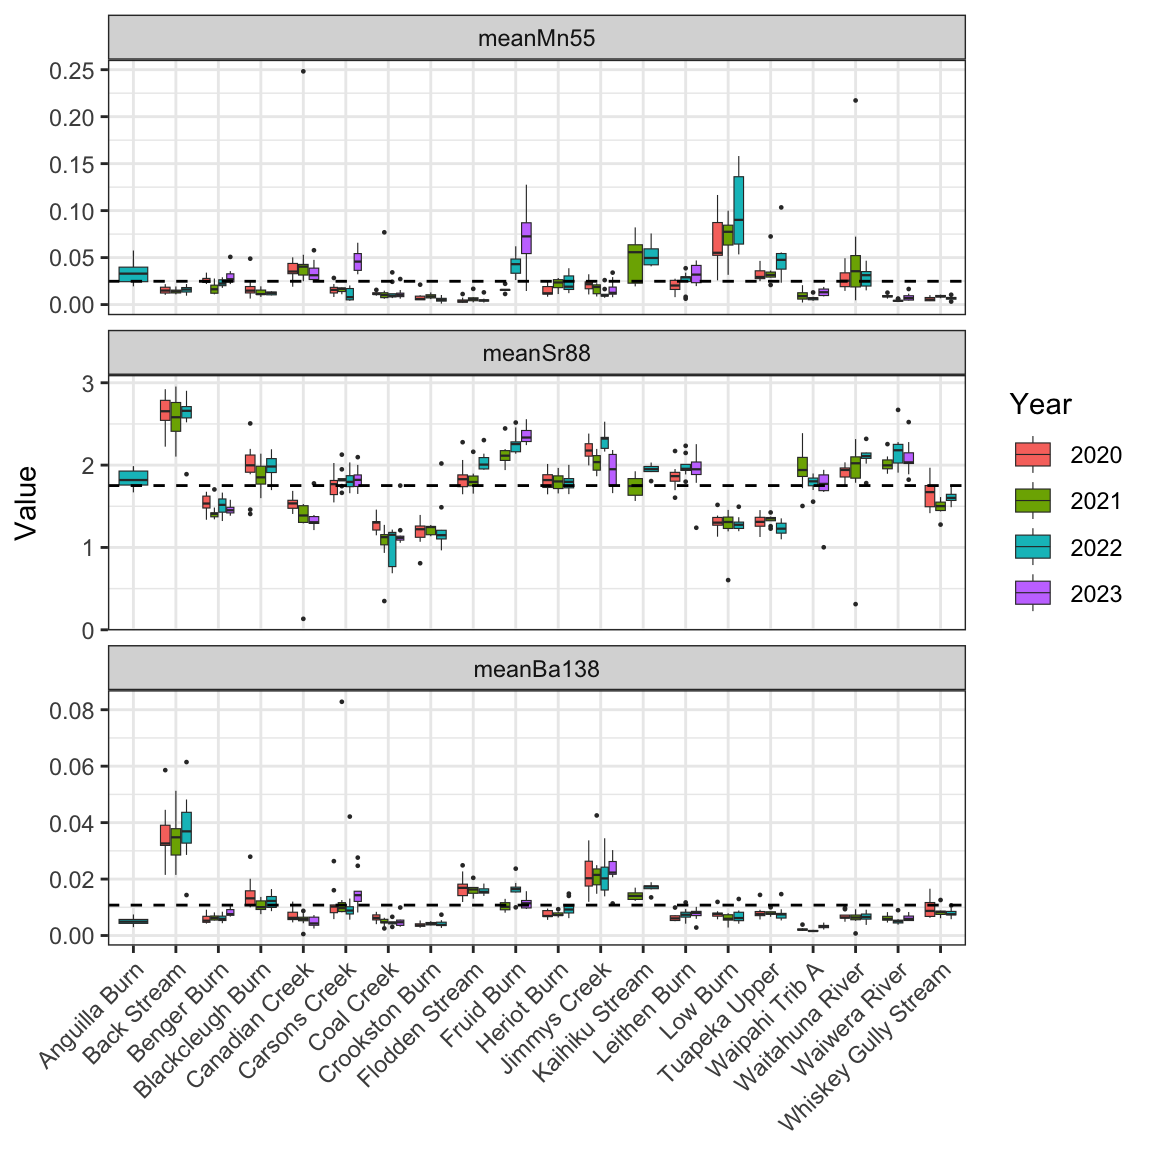
<figcaption>Figure 2: Boxplots showing the mean of the three selected elements Mn, Sr, Ba in element:Ca ratio in mmol/mol. Divided over the 20 sites and years (colours). The mean of all sites (dashed line).</figcaption>
</figure>

## Spatial variability

The elements Mn, Sr, and Ba were also selected as spatial variable as they did show significant differences across sites (<a href="#tbl-element-selection-static" class="quarto-xref">Table 1</a>). The RF model based on these three elements correctly assigned 0.598639% of samples to their original stream of origin (<a href="#tbl-rf" class="quarto-xref">Table 3</a>). The highest classification accuracies were observed for Back Stream, Flodden Stream, Waipahi Tributary A, and Whiskey Gully Stream, each with over 80% correct assignments. In contrast, Carsons Creek had the lowest classification accuracy at just 18%. The LDA model achieved a slightly lower overall accuracy of 52.7731092% based on leave-one-out cross-validation (<a href="#tbl-lda" class="quarto-xref">Table 4</a>). Back Stream, Benger Burn, and Coal Creek had the highest LDA assignment accuracy, each exceeding 80%, while Anguilla Burn and Crookston Burn had the lowest, with 0% of samples correctly assigned. The LDA model scatterplot illustrates how stream signatures cluster in multivariate space (<a href="#fig-lda" class="quarto-xref">Figure 3</a>). The spatial variation between the sites is present but there is substantial overlap. This overlap likely contributes to the moderate LDA classification accuracy, as it makes it more difficult to distinguish among certain sites based on their elemental profiles alone.

``` python
### Fit to the entire dataset
lda_model <- MASS::lda(Site ~ ., data = df_mean_juv_clean_main)

# In-sample predictions (scores, classes, posteriors)
pred <- predict(lda_model, newdata = df_mean_juv_clean_main)

predicted_labels_J <- pred$class
accuracy_score <- mean(predicted_labels_J == df_mean_juv_clean_main$Site)

posterior_probs_J <- pred$posterior
high_probs_J <- apply(posterior_probs_J, 1, max)

# LDA scores (linear discriminant coordinates)
lda_scores <- pred$x

# Attach IDs and predictors for plotting/export (aligned because we only dropped NAs before)
JdfII <- cbind(
  df_main_full[, c("meanMn55", "meanSr88", "meanBa138"), drop = FALSE],
  Slide_code = df_main_full$Slide_code,
  Year = df_main_full$Year,
  Site = df_main_full$Site,
  predicted_site = predicted_labels_J,
  highest_probs = high_probs_J
)

LD <- cbind(JdfII, LD1 = lda_scores[, 1], LD2 = lda_scores[, 2])

Juv_results <- LD


# Plot
# Scatterplot colored by predicted site
LDA_Plot_all <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = predicted_site), color = "black", shape = 21) +
  stat_ellipse(aes(col = predicted_site), level = 0.95) +
  theme_bw()

# Scatterplot of LD1 vs LD2, colored by Year, faceted by Site
lda_plot <- ggplot(Juv_results, aes(x = LD1, y = LD2)) +
  stat_ellipse(aes(col = as.factor(Year)), level = 0.95) +
  geom_point(aes(fill = as.factor(Year)), color = "black", shape = 21) +
  labs(x = "LD1", y = "LD2", fill = "Year", color = "Year") +
  facet_wrap(~Site) +
  theme_bw()

ggsave(
  lda_plot,
  file = file.path(out_dir, "fig-lda.png"),
  width = 8,
  height = 6,
  bg = "white",
  dpi = 600
)
```

    Warning in MASS::cov.trob(data[, vars], wt = weight * nrow(data)): Probable
    convergence failureWarning in MASS::cov.trob(data[, vars], wt = weight * nrow(data)): Probable
    convergence failure

<figure id="fig-lda">
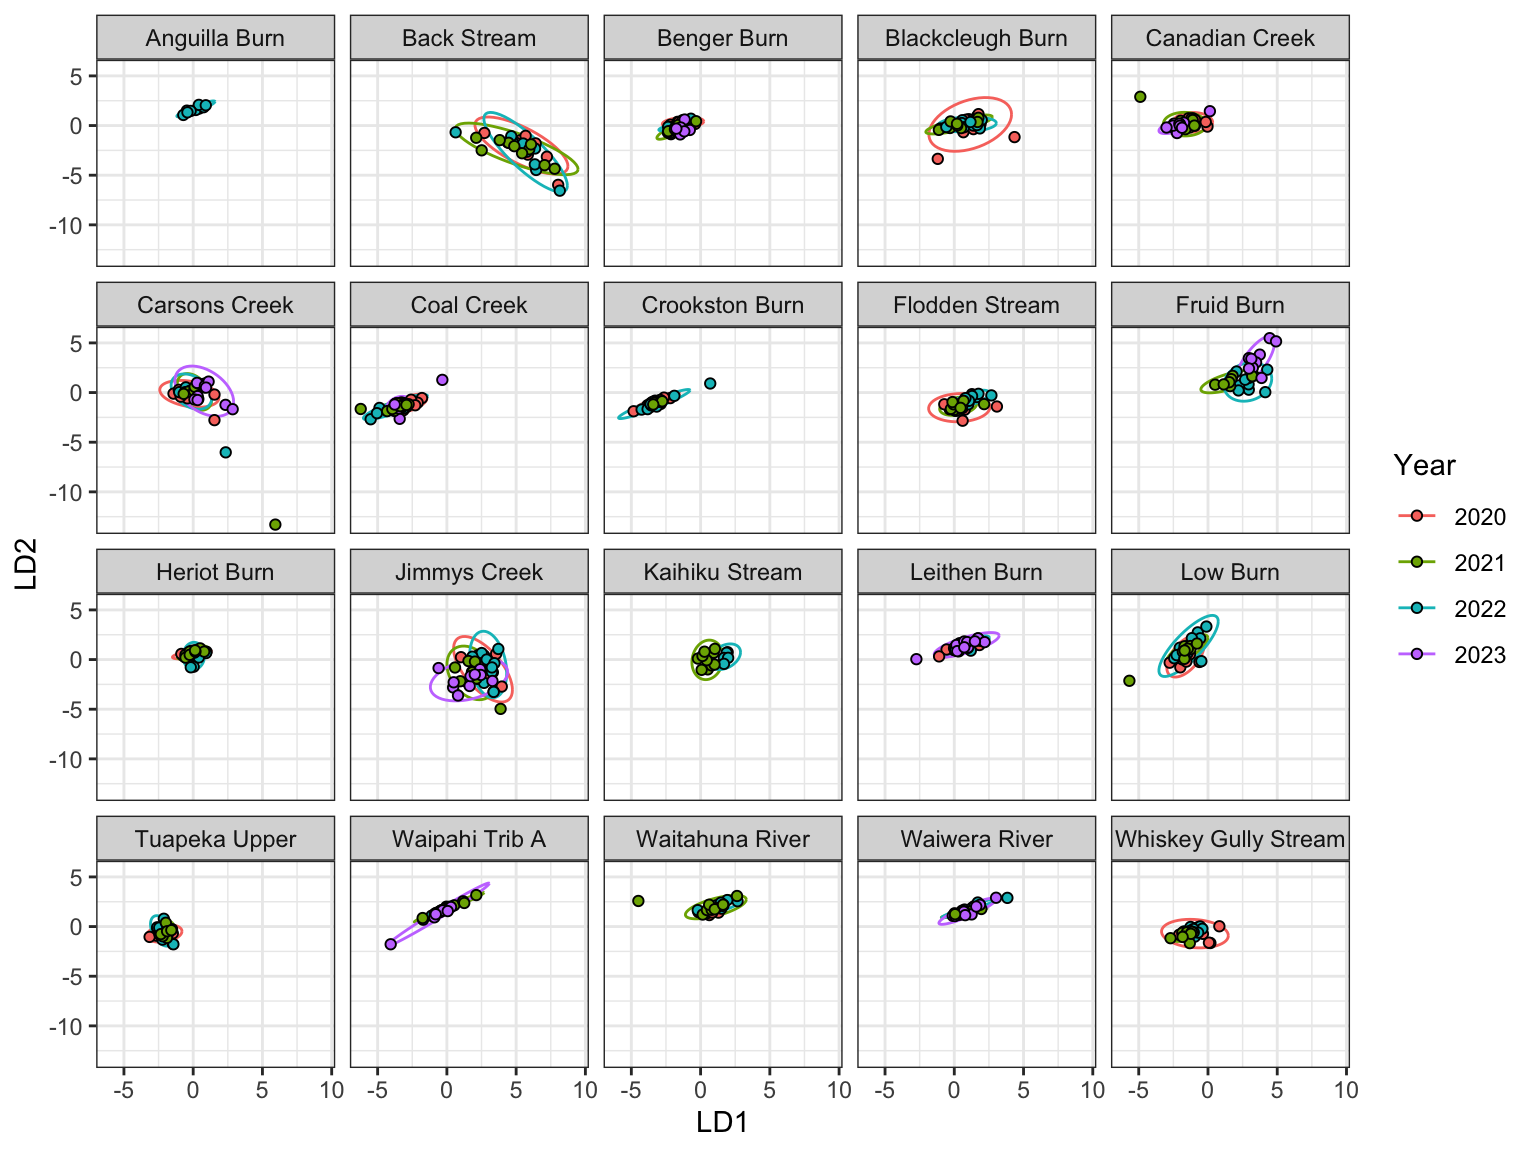
<figcaption>Figure 3: Scatterplots of LD1 vs LD2 variation of the trace element signatures of elements Mn, Sr, and Ba from the four years divided over the 20 sites. Points in each plot depict individual fish. Ellipses show 0.95 confidence interval for each year for each site. LD1 explains 63.47 %, LD2 explains 22.42 % of the total variance.</figcaption>
</figure>

``` python
df_mean_juv_clean_main <- df_mean_juv_clean %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# Fixed seed: randomForest() bootstrap-samples and picks split variables at
# random, so accuracy drifts a little on every re-render without this. Added
# after publication — results are stable from here on, but this exact seed
# was not used for the numbers printed in the published article.
set.seed(42)
rf_model <- randomForest(
  Site ~ .,
  data = df_mean_juv_clean_main,
  ntree = 400,
  importance = TRUE
)

conf_matrix <- rf_model$confusion

correct_predictions <- sum(diag(conf_matrix))
total_predictions <- sum(conf_matrix)
accuracy_rf <- correct_predictions / total_predictions

# Remove the class.error column for display
conf_display_rf <- conf_matrix[, !colnames(conf_matrix) %in% "class.error"]

# Add class error as % column
class_error_pct <- paste0(round(conf_matrix[, "class.error"] * 100, 1), "%")

conf_display_rf <- cbind(
  as.data.frame(conf_display_rf),
  `Class error` = class_error_pct
)

write.csv(
  conf_matrix,
  file = file.path(out_dir, "rf_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_rf, rownames_to_stub = TRUE)
```

|  | Anguilla Burn | Back Stream | Benger Burn | Blackcleugh Burn | Canadian Creek | Carsons Creek | Coal Creek | Crookston Burn | Flodden Stream | Fruid Burn | Heriot Burn | Jimmys Creek | Kaihiku Stream | Leithen Burn | Low Burn | Tuapeka Upper | Waipahi Trib A | Waitahuna River | Waiwera River | Whiskey Gully Stream | Class error |
|-----|---:|--:|--:|----:|---:|---:|--:|---:|---:|--:|--:|--:|---:|---:|--:|---:|---:|---:|---:|---:|:---|
| Anguilla Burn | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 2 | 6 | 0 | 0 | 81.8% |
| Back Stream | 0 | 25 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 5 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 16.7% |
| Benger Burn | 0 | 0 | 25 | 0 | 7 | 1 | 1 | 0 | 0 | 0 | 4 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 35.9% |
| Blackcleugh Burn | 0 | 1 | 0 | 12 | 0 | 5 | 0 | 0 | 0 | 3 | 2 | 3 | 1 | 0 | 1 | 0 | 0 | 0 | 1 | 1 | 60% |
| Canadian Creek | 0 | 0 | 8 | 0 | 16 | 2 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 2 | 1 | 0 | 1 | 0 | 0 | 50% |
| Carsons Creek | 0 | 0 | 2 | 5 | 0 | 8 | 0 | 0 | 1 | 0 | 5 | 4 | 5 | 2 | 0 | 0 | 0 | 2 | 2 | 3 | 79.5% |
| Coal Creek | 1 | 0 | 0 | 0 | 1 | 0 | 29 | 3 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 1 | 0 | 0 | 0 | 3 | 27.5% |
| Crookston Burn | 0 | 0 | 1 | 0 | 0 | 0 | 9 | 15 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 1 | 44.4% |
| Flodden Stream | 0 | 0 | 0 | 1 | 0 | 2 | 0 | 0 | 24 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 17.2% |
| Fruid Burn | 0 | 1 | 0 | 3 | 0 | 0 | 0 | 0 | 0 | 19 | 1 | 3 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 32.1% |
| Heriot Burn | 0 | 0 | 4 | 2 | 0 | 11 | 0 | 0 | 0 | 0 | 9 | 0 | 0 | 3 | 0 | 0 | 0 | 0 | 1 | 0 | 70% |
| Jimmys Creek | 0 | 1 | 0 | 2 | 0 | 1 | 0 | 0 | 1 | 3 | 0 | 32 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 22% |
| Kaihiku Stream | 0 | 0 | 0 | 0 | 0 | 4 | 0 | 0 | 0 | 0 | 0 | 0 | 11 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 31.2% |
| Leithen Burn | 3 | 0 | 1 | 0 | 2 | 1 | 0 | 0 | 0 | 2 | 5 | 0 | 0 | 8 | 0 | 0 | 0 | 4 | 4 | 0 | 73.3% |
| Low Burn | 0 | 0 | 0 | 0 | 3 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 21 | 4 | 0 | 0 | 0 | 0 | 30% |
| Tuapeka Upper | 0 | 0 | 3 | 0 | 2 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 3 | 20 | 0 | 0 | 0 | 0 | 31% |
| Waipahi Trib A | 0 | 0 | 1 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 24 | 0 | 1 | 0 | 11.1% |
| Waitahuna River | 3 | 0 | 0 | 0 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 9 | 0 | 0 | 0 | 14 | 1 | 0 | 51.7% |
| Waiwera River | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 2 | 0 | 0 | 1 | 1 | 23 | 0 | 17.9% |
| Whiskey Gully Stream | 0 | 0 | 0 | 0 | 0 | 2 | 1 | 0 | 3 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 24 | 20% |

Table 3: RF model confusion matrix of the 602 signatures tested. Actual shown in columns and predicted shown in rows. Overall accuracy: 61.0% (367 of 602 correct).

``` python
# Build a single working frame
df_main_full <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_main)) %>%
  tidyr::drop_na(dplyr::all_of(vars_main))

df_mean_juv_clean_main <- df_main_full %>%
  dplyr::select(Site, dplyr::all_of(vars_main))

# LOOCV
num_folds <- nrow(df_mean_juv_clean_main)
accuracy_scores <- numeric(num_folds)
partition_indices <- seq_len(num_folds)

site_levels <- levels(as.factor(df_mean_juv_clean_main$Site))
K <- length(site_levels)
class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = site_levels, Actual = site_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- df_mean_juv_clean_main[
    partition_indices != i,
    ,
    drop = FALSE
  ]
  testing_data <- df_mean_juv_clean_main[partition_indices == i, , drop = FALSE]

  lda_model_cv <- MASS::lda(Site ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)
  predicted_labels <- pred_cv$class

  accuracy_scores[i] <- mean(predicted_labels == testing_data$Site)

  tbl <- table(
    factor(predicted_labels, levels = site_levels),
    factor(testing_data$Site, levels = site_levels)
  )
  class_table <- class_table + tbl
}

mean_accuracy <- mean(accuracy_scores)
sum_accuracy <- sum(accuracy_scores)
sd_accuracy <- sd(accuracy_scores)
se_accuracy <- sd_accuracy / sqrt(length(accuracy_scores))
accuracy_lda <- mean_accuracy * 100

# Convert matrix to wide data frame correctly
conf_wide <- as.data.frame.matrix(class_table)

# Add class error column
class_error_pct <- paste0(
  round(
    (1 - diag(class_table) / rowSums(class_table)) * 100,
    1
  ),
  "%"
)

conf_display_lda <- cbind(conf_wide, `Class error` = class_error_pct)


write.csv(
  conf_display_lda,
  file = file.path(out_dir, "lda_conf_matrix.csv"),
  row.names = TRUE
)

knitr::kable(conf_display_lda, rownames_to_stub = TRUE)
```

|  | Anguilla Burn | Back Stream | Benger Burn | Blackcleugh Burn | Canadian Creek | Carsons Creek | Coal Creek | Crookston Burn | Flodden Stream | Fruid Burn | Heriot Burn | Jimmys Creek | Kaihiku Stream | Leithen Burn | Low Burn | Tuapeka Upper | Waipahi Trib A | Waitahuna River | Waiwera River | Whiskey Gully Stream | Class error |
|-----|---:|--:|--:|----:|---:|---:|--:|---:|---:|--:|--:|--:|---:|---:|--:|---:|---:|---:|---:|---:|:---|
| Anguilla Burn | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | NaN% |
| Back Stream | 0 | 25 | 0 | 1 | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 4 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 21.9% |
| Benger Burn | 0 | 0 | 34 | 0 | 18 | 4 | 2 | 1 | 0 | 0 | 3 | 0 | 0 | 2 | 1 | 10 | 2 | 0 | 0 | 3 | 57.5% |
| Blackcleugh Burn | 0 | 0 | 0 | 11 | 0 | 2 | 0 | 0 | 6 | 1 | 2 | 3 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 57.7% |
| Canadian Creek | 0 | 0 | 1 | 1 | 9 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 7 | 0 | 0 | 0 | 0 | 0 | 50% |
| Carsons Creek | 0 | 1 | 0 | 5 | 2 | 6 | 0 | 0 | 6 | 0 | 2 | 1 | 5 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 78.6% |
| Coal Creek | 0 | 0 | 1 | 0 | 1 | 0 | 37 | 23 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 3 | 1 | 0 | 0 | 1 | 45.6% |
| Crookston Burn | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0% |
| Flodden Stream | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 12 | 0 | 0 | 4 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 2 | 36.8% |
| Fruid Burn | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 19 | 0 | 2 | 0 | 0 | 0 | 0 | 0 | 3 | 1 | 0 | 24% |
| Heriot Burn | 2 | 0 | 3 | 6 | 0 | 11 | 1 | 0 | 0 | 1 | 19 | 0 | 0 | 7 | 0 | 0 | 1 | 0 | 1 | 0 | 63.5% |
| Jimmys Creek | 0 | 4 | 0 | 1 | 0 | 3 | 0 | 0 | 3 | 3 | 0 | 25 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 37.5% |
| Kaihiku Stream | 0 | 0 | 0 | 0 | 0 | 3 | 0 | 0 | 0 | 0 | 0 | 0 | 7 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 30% |
| Leithen Burn | 2 | 0 | 0 | 1 | 0 | 2 | 0 | 0 | 0 | 2 | 3 | 0 | 0 | 6 | 0 | 0 | 0 | 11 | 1 | 0 | 78.6% |
| Low Burn | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 3 | 0 | 20 | 2 | 0 | 1 | 0 | 0 | 25.9% |
| Tuapeka Upper | 0 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 14 | 0 | 0 | 0 | 0 | 12.5% |
| Waipahi Trib A | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 | 0 | 2 | 0 | 0 | 18 | 0 | 4 | 0 | 33.3% |
| Waitahuna River | 5 | 0 | 0 | 0 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 10 | 0 | 0 | 0 | 7 | 0 | 0 | 70.8% |
| Waiwera River | 0 | 0 | 0 | 1 | 0 | 1 | 0 | 1 | 0 | 2 | 0 | 1 | 0 | 3 | 0 | 0 | 5 | 7 | 21 | 0 | 50% |
| Whiskey Gully Stream | 0 | 0 | 0 | 2 | 0 | 3 | 0 | 1 | 2 | 0 | 0 | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 23 | 28.1% |

Table 4: LDA model confusion matrix of the 602 signatures tested by 602 folds of cross validation. Actual shown in columns and predicted shown in rows. The diagonal bold numbers are the correct predictions for each site.

The NNCA dendrogram based on the Silhouette Index show three main clusters of the 20 sites (<a href="#fig-nnca" class="quarto-xref">Figure 4</a>). Consistent with the data (<a href="#fig-main-elements" class="quarto-xref">Figure 2</a>), Back Stream is distinct from the other sites forming cluster a. Back Stream show higher values for the elements Sr and Ba compared to the other sites. The RF and LDA model where also used to predict the signatures for each cluster, which resulted in an accuracy score of 92.2689076% and 92.2689076% (<a href="#tbl-conf-nnca" class="quarto-xref">Table 5</a>). The LDA model scatterplot also shows the three distinct clusters, with more overlap in cluster b and c (<a href="#fig-nnca-lda" class="quarto-xref">Figure 5</a>).

``` python
# Calculate mean elemental composition per site
mean_by_group <- aggregate(
  cbind(meanMn55, meanSr88, meanBa138) ~ Site,
  data = Juv_results,
  FUN = mean
)

# 1) Prepare matrix with Site names as row names (no reordering)
#    Assumes mean_by_group has first column 'Site' and remaining numeric features
data_mat <- as.matrix(mean_by_group[, -1, drop = FALSE])
rownames(data_mat) <- mean_by_group$Site

# 2) Distance + clustering (same as before)
distance_matrix <- dist(data_mat)
fit <- hclust(distance_matrix, method = "single")

# 3) Determine optimal cluster count via silhouette (same logic)
k_max <- max(2, min(19, nrow(mean_by_group) - 1))
sil_scores <- sapply(2:k_max, function(k) {
  grp <- cutree(fit, k = k)
  mean(silhouette(grp, distance_matrix)[, "sil_width"])
})
optimal_clusters <- which.max(sil_scores) + 1

# 4) Convert to ggdendro data; labels come directly from hclust (Site names via rownames)
dd <- ggdendro::dendro_data(fit, type = "rectangle")

# 5) Right panel: horizontal dendrogram (suppress leaf labels here to avoid duplication)
dend_plot <- ggplot() +
  geom_segment(
    data = dd$segments,
    aes(x = y, y = x, xend = yend, yend = xend),
    linewidth = 0.3
  ) +
  labs(x = "Distance between sites", y = NULL) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    plot.title.position = "plot"
  )

# 6) Left panel: Site labels in dendrogram leaf order (already Site names)
labels_df <- dd$labels
labels_df$y <- labels_df$x
left_labels <- ggplot(labels_df, aes(x = 1, y = y, label = label)) +
  geom_text(hjust = 1) +
  xlim(0.5, 1.02) +
  labs(x = NULL, y = NULL) +
  theme_void()

# 7) Combine panels: LEFT labels (narrow) + RIGHT tree (wide)
NNCA_tree_plot <- left_labels +
  dend_plot +
  patchwork::plot_layout(widths = c(1, 1))

ggsave(
  NNCA_tree_plot,
  file = file.path(out_dir, " fig-nnca.png"),
  width = 4,
  height = 5,
  dpi = 600
)

NNCA_tree_plot
```

<figure id="fig-nnca">
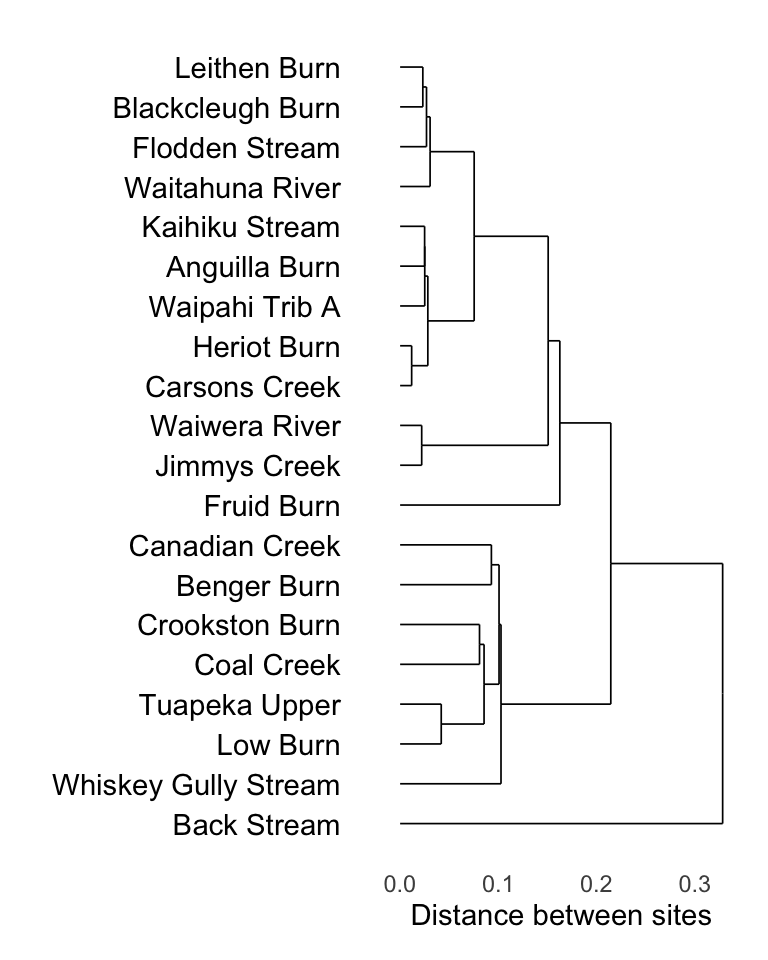
<figcaption>Figure 4: Dendrogram of the Nearest-Neighbour Cluster Analysis of the trace element signatures of elements Mn, Sr, and Ba from the four years. Based on the Silhouette index, three clusters were selected.</figcaption>
</figure>

``` python
# Assign cluster numbers to each Catch_location
mean_by_group$NNCA <- cutree(fit, k = optimal_clusters)

# Merge NNCA data into Juv_results based on Catch_location
Juv_results_NNCA <- Juv_results %>%
  dplyr::left_join(mean_by_group %>% dplyr::select(Site, NNCA), by = "Site")

# Select useful columns
Juv_NNCA <- Juv_results_NNCA %>%
  dplyr::select(meanMn55, meanSr88, meanBa138, NNCA) %>%
  dplyr::mutate(NNCA = as.factor(NNCA))

cluster_levels <- levels(Juv_NNCA$NNCA)
K <- length(cluster_levels)

### RF
# Fixed seed — see note by the first randomForest() call above.
set.seed(42)
rf_model_nnca <- randomForest(
  NNCA ~ .,
  data = Juv_NNCA,
  ntree = 400,
  importance = TRUE
)

conf_rf <- rf_model_nnca$confusion[, cluster_levels] # drop class.error
accuracy_rf_nnca <- sum(diag(conf_rf)) / sum(conf_rf)
accuracy_rf_nnca <- accuracy_rf_nnca * 100

### LDA - LOOCV confusion matrix
num_folds <- nrow(Juv_NNCA)
accuracy_scores_lda <- numeric(num_folds)

lda_class_table <- matrix(
  0,
  nrow = K,
  ncol = K,
  dimnames = list(Predicted = cluster_levels, Actual = cluster_levels)
)

for (i in seq_len(num_folds)) {
  training_data <- Juv_NNCA[-i, ]
  testing_data <- Juv_NNCA[i, , drop = FALSE]

  lda_model_cv <- MASS::lda(NNCA ~ ., data = training_data)
  pred_cv <- predict(lda_model_cv, newdata = testing_data)$class

  accuracy_scores_lda[i] <- mean(pred_cv == testing_data$NNCA)

  tbl_i <- table(
    factor(pred_cv, levels = cluster_levels),
    factor(testing_data$NNCA, levels = cluster_levels)
  )
  lda_class_table <- lda_class_table + tbl_i
}

mean_accuracy_lda <- mean(accuracy_scores_lda)
accuracy_lda_nnca <- sum(diag(lda_class_table)) / sum(lda_class_table)
accuracy_lda_nnca <- accuracy_lda_nnca * 100
# Final LDA for LD scores (plot use)
lda_model_final <- MASS::lda(NNCA ~ ., data = Juv_NNCA)
predicted_labels <- predict(lda_model_final, newdata = Juv_NNCA)$class
LD <- predict(lda_model_final)$x

Juv_NNCA2 <- cbind(
  Juv_NNCA,
  predicted_labels = predicted_labels,
  LD1 = LD[, 1],
  LD2 = LD[, 2]
) %>%
  dplyr::mutate(Correct = ifelse(NNCA == predicted_labels, "1", "0"))

# ---- Build side-by-side table ----

conf_rf_wide <- as.data.frame.matrix(conf_rf[, cluster_levels])
conf_lda_wide <- as.data.frame.matrix(lda_class_table)

combined <- cbind(conf_rf_wide, conf_lda_wide)

# Move rownames to explicit column
combined_display <- data.frame(
  Predicted = cluster_levels,
  combined,
  check.names = FALSE
)

# Rename to avoid duplicates
colnames(combined_display) <- c(
  "Predicted",
  paste0("RF_", cluster_levels),
  paste0("LDA_", cluster_levels)
)

write.csv(
  combined_display,
  file = file.path(out_dir, "combined_nnca_conf_matrix.csv"),
  row.names = TRUE
)


knitr::kable(combined_display)
```

| Predicted | RF_1 | RF_2 | RF_3 | LDA_1 | LDA_2 | LDA_3 |
|:----------|-----:|-----:|-----:|------:|------:|------:|
| 1         |  322 |    2 |   14 |   317 |     4 |    21 |
| 2         |    5 |   25 |    0 |     8 |    26 |     0 |
| 3         |   18 |    0 |  209 |    13 |     0 |   206 |

Table 5: Confusion matrix of the RF and LDA of the tree clusters from the NNCA. Actual shown in columns and predicted shown in rows. The diagonal bold numbers are the correct predictions for each cluster.

``` python
# Create a column to indicate correctness of prediction
Juv_NNCA2$Correct <- ifelse(
  Juv_NNCA2$NNCA == Juv_NNCA2$predicted_labels,
  "1",
  "0"
)

# Plot with correctly classified in black, misclassified in white
LDA_NNCA <- ggplot(Juv_NNCA2, aes(x = LD1, y = LD2)) +
  geom_point(aes(fill = Correct), color = 'black', shape = 21) +
  scale_fill_manual(values = c("1" = "black", "0" = "white")) +
  stat_ellipse(aes(col = NNCA), level = 0.95) +
  theme_bw()

ggsave(
  LDA_NNCA,
  file = file.path(out_dir, "fig-nnca-lda.png"),
  width = 5,
  height = 4,
  bg = "white",
  dpi = 600
)

LDA_NNCA
```

<figure id="fig-nnca-lda">
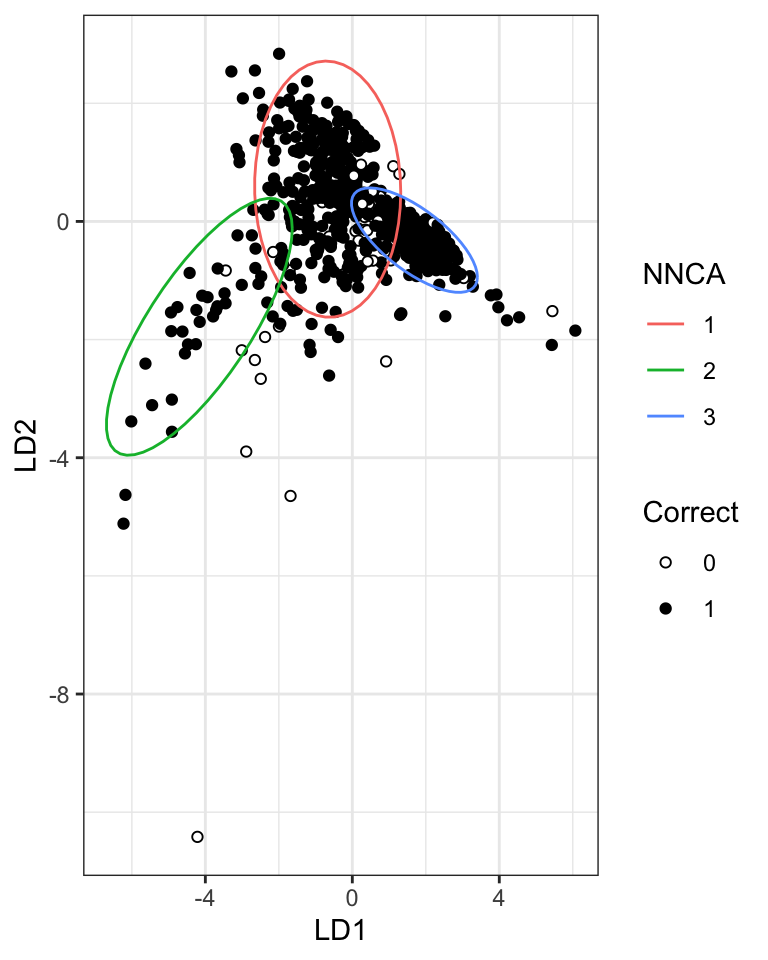
<figcaption>Figure 5: Scatterplots of LD1 vs LD2 variation of the trace element signatures of elements Mn, Sr, and Ba from the four years divided over the three clusters from the NNCA. Points are individual signatures and are coloured according to their prediction, 0 not correct, 1 correct predicted. Ellipses show 0.95 confidence interval, colours represent the different clusters, a: red (n=30), b: green (n=229), c: blue (n=343). LD1 explains 87.4 %, LD2 explains 12.6 % of the total variance.</figcaption>
</figure>

# Discussion

## Element selection

The elements Mn, Sr, and Ba were found to be temporally stable and spatially variable in trout otoliths from the lower Clutha river catchment, making them particularly useful for trace element analysis in the Clutha River catchment. These three elements have been widely used in both freshwater and saltwater studies ([Campana et al., 2000](#ref-Campana2000); [Gillanders, 2002](#ref-Gillanders2002); [Olley et al., 2011](#ref-Olley2011); [Secor & Rooker, 2000](#ref-Secor2000); [Swearer et al., 2003](#ref-Swearer2003); [Thorrold et al., 1998](#ref-Thorrold1998); [Wells et al., 2003](#ref-Wells2003)). In contrast, elements such as Li, Mg, and Rb exhibited insufficient temporal stability or spatial variability in this study and were therefore excluded from further analysis, although they have been used in other studies. Physiological regulation of elements can vary between fish species ([Campana, 1999](#ref-Campana1999)), and individual differences in elemental signatures may also result from physiological variation ([Sturrock et al., 2015](#ref-Sturrock2015)), both of which can influence the temporal stability and spatial variability of certain elements.

## Temporal stability

The temporal stability of the three selected elements showed almost no interannual variability within sites, a pattern consistent with findings from the existing freshwater literature ([Martin et al., 2013](#ref-Martin2013); [Matetski et al., 2021](#ref-Matetski2021); [Nazir & Khan, 2019](#ref-Nazir2019); [Rowles et al., 2021](#ref-Rowles2021); [Swearer et al., 2003](#ref-Swearer2003); [Thorrold et al., 1998](#ref-Thorrold1998)). In river systems, trace elements are generally expected to be temporally stable unless impacted by anthropogenic or natural changes to upstream catchments, which can alter elemental compositions through factors such as industrial discharges ([Long et al., 2021](#ref-Long2021)) - this includes agricultural runoff ([Mununga Katebe et al., 2023](#ref-MunungaKatebe2023)), or changes in land use ([Arfaeinia et al., 2019](#ref-Arfaeinia2019); [Mohammadi et al., 2023](#ref-Mohammadi2023)). As a result, the long-term stability of elemental signatures can be difficult to predict. Comparing otolith elemental concentrations of Mn, Sr, and Ba from samples collected in 2015 ([Svirgsden et al., 2018](#ref-Svirgsden2018)) with those from the present study, we observed variation in Mn and Ba, while Sr signatures remained stable over a period of more than five years.

While interannual variability was low, intra-annual variability may play a more significant role in freshwater systems. For example, increased precipitation (including snowmelt) or spring-fed flows, can lead to changes in runoff and thereby alter trace element signatures ([Crook et al., 2017](#ref-Crook2017)). This might explain the finer-scale temporal variability as observed in the Fruid Burn.

## Spatial variability

The observed spatial variability in the selected trace elements provides a basis for developing models to assess connectivity between juvenile and adult habitats. In this study, the performance of both the RF and the LDA models was evaluated, with predictions of origin sites being accurate 61% and 52% of the time, respectively. The 52% accuracy of the LDA model is lower than reported in other studies, where accuracies have ranged from 73% to 93% ([Martin et al., 2013](#ref-Martin2013); [Matetski et al., 2021](#ref-Matetski2021); [Mikheev et al., 2021](#ref-Mikheev2021); [Reis-Santos et al., 2012](#ref-ReisSantos2012)). This discrepancy may be due to the high degree of similarity between sites, as all sampled locations are relatively close together within the Clutha River catchment. The similarity among sites is further supported by the three clusters identified in the NNCA (<a href="#fig-nnca-lda" class="quarto-xref">Figure 5</a>), which achieved 93% classification accuracy using both the LDA and RF models. While both models performed similarly when classifying the clusters, the RF model outperformed the LDA model when applied to individual sites. This is consistent with findings from Mercier et al. ([2011](#ref-Mercier2011)), who demonstrated that RF models often yield superior results across multiple datasets. Unlike LDA, which assumes normally distributed data with equal covariance matrices across classes, RF makes no such assumptions, allowing greater flexibility and often higher accuracy in complex datasets.

The separation of the otolith trace element signatures into three clusters identified by the NNCA may be explained by underlying geological differences across the catchment (<a href="#fig-geology-map" class="quarto-xref">Figure 6</a>). Back Stream (cluster a, red) exhibited higher concentrations of Sr and Ba compared to the other sites (<a href="#fig-main-elements" class="quarto-xref">Figure 2</a>) and is the only stream draining from the south-eastern side of the Blue Mountains. In contrast, Blackcleugh Burn, Crookston Burn, Flodden Stream, and Whiskey Gully Stream, which originate from a different part of the Blue Mountains, showed average or below-average Sr and Ba concentrations and were grouped into clusters b and c. The underlying cause of this difference remains unclear but may relate to site-specific erosion processes, as soil weathering is a major source of elements like Sr and Ba ([Lučić et al., 2022](#ref-Lui2022)). Sites in cluster b (green) are primarily located in areas dominated by gravel, limestone, and mudstone, whereas sites in cluster c (blue) are predominantly situated in sandstone regions. Although Fruid Burn (cluster c) is geographically close to several sites from cluster b, it is clearly positioned within cluster c (<a href="#fig-nnca-lda" class="quarto-xref">Figure 5</a>).

<figure id="fig-geology-map">
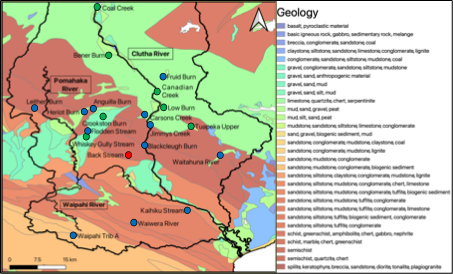
<figcaption>Figure 6: Geological map of the lower Clutha catchment with the research sites. Coloured from the scatterplot clusters of the NNCA figure 6 (a: red, b: green, c: blue). After: <span class="citation" data-cites="MFE2010">Ministry for the Environment (<a href="#ref-MFE2010" role="doc-biblioref">2010</a>)</span>, <span class="citation" data-cites="Heron2023">Heron (<a href="#ref-Heron2023" role="doc-biblioref">2023</a>)</span> GNS Science. This map was created using QGIS software by Esri.</figcaption>
</figure>

## Conclusion

In conclusion, this research investigated the temporal stability of trace element signatures in juvenile brown trout otoliths, aiming to ascertain their consistency and suitability for inter-generational tracking of the natal streams of adult brown trout. The elements Mn, Sr, and Ba showed generally temporal stability and spatial variability within the Clutha River catchment. However, the subtle differences in trace element signatures made some predictions less precise. By clustering the sites increase the classification accuracy where achieved. This suggests that temporal variation does not prevent the use of juvenile otoliths from different years in determining natal origins across generations in this catchment. We suggest that it is not always crucial to determine the age of adult fish and compare their birth year with juveniles from the same year. However, it is advised to have a database of juveniles from a 2–3-year range to train the model. These juveniles should preferably be caught in the same part of the year to reduce the possible effect of intra-annual variation. However, given that signatures may drift over time, it is advisable to periodically re-calibrate the models by collecting fresh samples of juvenile fish from key sub-catchments.

Whilst individual streams were not always clearly separated across the Pomahaka River catchment, trace element analysis of otoliths did resolve fish with reasonable accuracy to groups of streams. By combining trace element analysis of otoliths with other sources of information on reproductive activity, such as spawning surveys, redd counts, and assessments of juvenile abundance, identification and understanding of relationships between migration and recruitment across catchments can be significantly improved. Routine incorporation of trace element analysis into the toolset available to fisheries managers equips them with a key source of information that allows identification of likely source streams for recruits which will enable better spatial management of migratory salmonid populations.

# Acknowledgments

This project was funded by Contact Energy Ltd and executed by the Otago Fish and Game Council in cooperation with the University of Otago, Department of Zoology. The writers want to thank Fish & Game staff and volunteers particularly Steve Dixon for collecting samples. Thanks also to University of Otago staff, the Department of Geology, for the support and the time with the laser and Ryan Easton from the Department of Zoology for explaining and helping with the implementation of the methods and all the other support. And finally, thanks to Leo Nagelkerke for guidance and feedback. We thank two anonymous reviewers for constructive comments on an earlier version of this article.

# Contributions

The contributions of each author, including ideas (G.P.C.), Sampling design (H.T.), data collection (J.E.M.C.), data analysis (O.V.R., M.R.R.), manuscript preparation (O.V.R.), and manuscript revision (J.E.M.C., M.R.R., G.P.C., O.V.R., R.S, M.R.).

# Data availability statement

Additional data contact the corresponding author.

# Ethics declarations

Conflict of interests. The authors declare that they have no conflicts of interest.

Statement on the welfare of humans or animals. All applicable international, national, and/or institutional guidelines for the care and use of animals were followed.

# References

Arfaeinia, H., Dobaradaran, S., Moradi, M., Pasalari, H., Mehrizi, E. A., Taghizadeh, F., Esmaili, A., & Ansarizadeh, M. (2019). The effect of land use configurations on concentration, spatial distribution, and ecological risk of heavy metals in coastal sediments of northern part along the persian gulf. *Science of The Total Environment*, *653*, 783–791. <https://doi.org/10.1016/j.scitotenv.2018.11.009>

Aschenbrenner, A., Ferreira, B. P., & Rooker, J. R. (2016). Spatial and temporal variability in the otolith chemistry of the brazilian snapper lutjanus alexandrei from estuarine and coastal environments. *Journal of Fish Biology*, *89*(1), 753–769. <https://doi.org/10.1111/jfb.13003>

Campana, S. E. (1999). Chemistry and composition of fish otoliths:pathways, mechanisms and applications. *Marine Ecology Progress Series*, *188*, 263–297. <https://doi.org/10.3354/meps188263>

Campana, S. E., Chouinard, G. A., Hanson, J. M., Fréchet, A., & Brattey, J. (2000). Otolith elemental fingerprints as biological tracers of fish stocks. *Fisheries Research*, *46*(1–3), 343–357. <https://doi.org/10.1016/s0165-7836(00)00158-2>

Carlson, A. K., Phelps, Q. E., & Graeb, B. D. S. (2016). Chemistry to conservation: Using otoliths to advance recreational and commercial fisheries management. *Journal of Fish Biology*, *90*(2), 505–527. <https://doi.org/10.1111/jfb.13155>

Clarke, L., Walther, B., Munch, S., Thorrold, S., & Conover, D. (2009). Chemical signatures in the otoliths of a coastal marine fish, menidia menidia, from the northeastern united states: Spatial and temporal differences. *Marine Ecology Progress Series*, *384*, 261–271. <https://doi.org/10.3354/meps07927>

Crook, D. A., Lacksen, K., King, A. J., Buckle, D. J., Tickell, S. J., Woodhead, J. D., Maas, R., Townsend, S. A., & Douglas, M. M. (2017). Temporal and spatial variation in strontium in a tropical river: Implications for otolith chemistry analyses of fish migration. *Canadian Journal of Fisheries and Aquatic Sciences*, *74*(4), 533–545. <https://doi.org/10.1139/cjfas-2016-0153>

Eggins, S., Grün, R., Pike, A. W. G., Shelley, M., & Taylor, L. (2003). 238U, 232Th profiling and u-series isotope analysis of fossil teeth by laser ablation-ICPMS. *Quaternary Science Reviews*, *22*(10–13), 1373–1382. <https://doi.org/10.1016/s0277-3791(03)00064-7>

Elliott, J. M. (1994). *Quantitative ecology and the brown trout*. Oxford University PressOxford. <https://doi.org/10.1093/oso/9780198546788.001.0001>

Elsdon, T. S., & Gillanders, B. M. (2006). Temporal variability in strontium, calcium, barium, and manganese in estuaries: Implications for reconstructing environmental histories of fish from chemicals in calcified structures. *Estuarine, Coastal and Shelf Science*, *66*(1–2), 147–156. <https://doi.org/10.1016/j.ecss.2005.08.004>

Elsdon, T. S., Wells, B. K., Campana, S. E., Gillanders, B. M., Jones, C. M., Limburg, K. E., Secor, D. H., Thorrold, S. R., & Walther, B. D. (2008). Otolith chemistry to describe movements and life -history parameters of fishes: Hypotheses, assumptions, limitations and inferences. In *In Oceanography and marine biology* (pp. 303–336). CRC Press. https://doi.org/<https://doi.org/10.1201/9781420065756-9>

Ferguson, A., Reed, T. E., Cross, T. F., McGinnity, P., & Prodöhl, P. A. (2019). Anadromy, potamodromy and residency in brown trout salmo trutta: The role of genes and the environment. *Journal of Fish Biology*, *95*(3), 692–718. <https://doi.org/10.1111/jfb.14005>

Gillanders, B. M. (2002). Temporal and spatial variability in elemental composition of otoliths: Implications for determining stock identity and connectivity of populations. *Canadian Journal of Fisheries and Aquatic Sciences*, *59*(4), 669–679. <https://doi.org/10.1139/f02-040>

Hamer, P., Jenkins, G., & Gillanders, B. (2003). Otolith chemistry of juvenile snapper pagrus auratus in victorian waters: Natural chemical tags and their temporal variation. *Marine Ecology Progress Series*, *263*, 261–273. <https://doi.org/10.3354/meps263261>

Hayes, J. W. (1988). Mortality and growth of juvenile brown and rainbow trout in a lake inlet nursery stream, new zealand. *New Zealand Journal of Marine and Freshwater Research*, *22*(2), 169–179. <https://doi.org/10.1080/00288330.1988.9516289>

Heron, D. W. (2023). *Geological map of new zealand 1:250 000*. GNS Science. <https://doi.org/10.21420/03PC-H178>

Jellyman, P. G., McHugh, P. A., Simon, K. S., Thompson, R. M., & McIntosh, A. R. (2017). *The effects of brown trout on the trophic webs of new zealand streams* (pp. 569–597). Wiley. <https://doi.org/10.1002/9781119268352.ch22>

Jones, C. M., & Chen, Z. (2003). New techniques for sampling larval and juvenile fish otoliths for trace-element analysis with laser-ablation sector-field inductively-coupled plasma mass spectrometry (SF-ICP-MS). In *The big fish bang: Proceedings of the 26th annual larval fish conference* (pp. 431–443). Institute of Marine Research.

Jonsson, B., & Jonsson, N. (2011). *Ecology of atlantic salmon and brown trout: Habitat as a template for life histories* (Vol. 33). Springer Science & Business Media.

Klemetsen, A., Amundsen, P. ‐A., Dempson, J. B., Jonsson, B., Jonsson, N., O’Connell, M. F., & Mortensen, E. (2003). Atlantic salmonSalmo salarL., brown troutSalmo truttaL. And arctic charrSalvelinus alpinus(l.): A review of aspects of their life histories. *Ecology of Freshwater Fish*, *12*(1), 1–59. <https://doi.org/10.1034/j.1600-0633.2003.00010.x>

Kristensen, E. A., & Closs, G. P. (2008). Environmental variability and population dynamics of juvenile brown trout (salmo trutta) in an upstream and downstream reach of a small new zealand river. *New Zealand Journal of Marine and Freshwater Research*, *42*(1), 57–71. <https://doi.org/10.1080/00288330809509936>

Land Information New Zealand (LINZ). (2025). *Various topographic datasets*. <https://data.linz.govt.nz/>.

Liaw, A., & Wiener, M. (2002). Classification and regression by <span class="nocase">randomForest</span>. *R News*, *2*(3), 18–22.

Loher, T., Bath, G. E., & Wischniowski, S. (2021). The potential utility of otolith microchemistry as an indicator of nursery origins in pacific halibut (hippoglossus stenolepis). *Fisheries Research*, *243*, 106072. <https://doi.org/10.1016/j.fishres.2021.106072>

Long, Z., Huang, Y., Zhang, W., Shi, Z., Yu, D., Chen, Y., Liu, C., & Wang, R. (2021). Effect of different industrial activities on soil heavy metal pollution, ecological risk, and health risk. *Environmental Monitoring and Assessment*, *193*(1). <https://doi.org/10.1007/s10661-020-08807-z>

Lučić, M., Mikac, N., Vdović, N., Bačić, N., Nava, V., Vidmar, J., & Milačič, R. (2022). Spatial and temporal variability and sources of dissolved trace elements in the sava river (slovenia, croatia). *Environmental Science and Pollution Research*, *29*(21), 31734–31748. <https://doi.org/10.1007/s11356-021-17769-9>

Martin, J., Bareille, G., Berail, S., Pecheyran, C., Daverat, F., Bru, N., Tabouret, H., & Donard, O. (2013). Spatial and temporal variations in otolith chemistry and relationships with water chemistry: A useful tool to distinguish atlantic salmon salmo salar parr from different natal streams. *Journal of Fish Biology*, *82*(5), 1556–1581. <https://doi.org/10.1111/jfb.12089>

Matetski, L., Rohtla, M., Svirgsden, R., Kesler, M., Saks, L., Taal, I., Hommik, K., Paiste, P., Kielman‐Schmitt, M., Kooijman, E., Birzaks, J., Saura, A., Ziņģis, M., Vaittinen, M., & Vetemaa, M. (2021). Variability in stream water chemistry and brown trout (salmo trutta l.) parr otolith microchemistry on different spatial scales. *Ecology of Freshwater Fish*, *31*(2), 438–453. <https://doi.org/10.1111/eff.12642>

Mercier, L., Darnaude, A. M., Bruguier, O., Vasconcelos, R. P., Cabral, H. N., Costa, M. J., Lara, M., Jones, D. L., & Mouillot, D. (2011). Selecting statistical models and variable combinations for optimal classification using otolith microchemistry. *Ecological Applications*, *21*(4), 1352–1364. <https://doi.org/10.1890/09-1887.1>

Mikheev, P. B., Jarvis, M. G., Matthaei, C. D., Ingram, T., Reid, M. R., Nikiforov, A. I., Chernienko, I. S., & Closs, G. P. (2021). Straying of brown trout in the catchment of a large new zealand river evaluated by otolith microchemistry. *Ecology of Freshwater Fish*, *30*(4), 433–443. <https://doi.org/10.1111/eff.12595>

Milton, D., Chenery, S., Farmer, M., & Blaber, S. (1997). Identifying the spawning estuaries of the tropical shad, terubok tenualosa toli, using otolith microchemistry. *Marine Ecology Progress Series*, *153*, 283–291. <https://doi.org/10.3354/meps153283>

Ministry for the Environment. (2010). *River environment classification new zealand 2010*. <https://data.mfe.govt.nz/layer/51845-river-environment-classification-new-zealand-2010/>.

Mohammadi, M., Egli, M., Kavian, A., & Lizaga, I. (2023). Static and dynamic source identification of trace elements in river and soil environments under anthropogenic activities in the haraz plain, northern iran. *Science of The Total Environment*, *892*, 164432. <https://doi.org/10.1016/j.scitotenv.2023.164432>

Mununga Katebe, F., Raulier, P., Colinet, G., Ngoy Shutcha, M., Mpundu Mubemba, M., & Jijakli, M. H. (2023). Assessment of heavy metal pollution of agricultural soil, irrigation water, and vegetables in and nearby the cupriferous city of lubumbashi, (democratic republic of the congo). *Agronomy*, *13*(2), 357. <https://doi.org/10.3390/agronomy13020357>

Nazir, A., & Khan, M. A. (2019). Spatial and temporal variation in otolith chemistry and its relationship with water chemistry: Stock discrimination of sperata aor. *Ecology of Freshwater Fish*, *28*(3), 499–511. <https://doi.org/10.1111/eff.12471>

Olley, R., Young, R., Closs, G., Kristensen, E., Bickel, T., Deans, N., Davey, L., & Eggins, S. (2011). Recruitment sources of brown trout identified by otolith trace element signatures. *New Zealand Journal of Marine and Freshwater Research*, *45*(3), 395–411. <https://doi.org/10.1080/00288330.2011.592196>

Otago Regional Council. (2023). *Land and water regional plan: Lower clutha rohe*. <https://www.orc.govt.nz/plans-policies-reports/land-and-water-regional-plan/find-your-area/lower-clutha-rohe>.

Paton, C., Hellstrom, J., Paul, B., Woodhead, J., & Hergt, J. (2011). Iolite: Freeware for the visualisation and processing of mass spectrometric data. *Journal of Analytical Atomic Spectrometry*, *26*(12), 2508. <https://doi.org/10.1039/c1ja10172b>

R Core Team. (2023). *R: A language and environment for statistical computing*. R Foundation for Statistical Computing. <https://www.R-project.org/>

Reis-Santos, P., Gillanders, B. M., Sturrock, A. M., Izzo, C., Oxman, D. S., Lueders-Dumont, J. A., Hüssy, K., Tanner, S. E., Rogers, T., Doubleday, Z. A., Andrews, A. H., Trueman, C., Brophy, D., Thiem, J. D., Baumgartner, L. J., Willmes, M., Chung, M.-T., Charapata, P., Johnson, R. C., … Walther, B. D. (2022). Reading the biomineralized book of life: Expanding otolith biogeochemical research and applications for fisheries and ecosystem-based management. *Reviews in Fish Biology and Fisheries*, *33*(2), 411–449. <https://doi.org/10.1007/s11160-022-09720-z>

Reis-Santos, P., Gillanders, B. M., Tanner, S. E., Vasconcelos, R. P., Elsdon, T. S., & Cabral, H. N. (2012). Temporal variability in estuarine fish otolith elemental fingerprints: Implications for connectivity assessments. *Estuarine, Coastal and Shelf Science*, *112*, 216–224. <https://doi.org/10.1016/j.ecss.2012.07.027>

Reis-Santos, P., Vasconcelos, R. P., Tanner, S. E., Fonseca, V. F., Cabral, H. N., & Gillanders, B. M. (2018). Extrinsic and intrinsic factors shape the ability of using otolith chemistry to characterize estuarine environmental histories. *Marine Environmental Research*, *140*, 332–341. <https://doi.org/10.1016/j.marenvres.2018.06.002>

Reis-Santos, P., Tanner, S., Vasconcelos, R., Elsdon, T., Cabral, H., & Gillanders, B. (2013). Connectivity between estuarine and coastal fish populations: Contributions of estuaries are not consistent over time. *Marine Ecology Progress Series*, *491*, 177–186. <https://doi.org/10.3354/meps10458>

Rowles, G., Wuellner, M. R., & Koupal, K. D. (2021). Spatial distinction and temporal stability of water microelements in the north platte river and lake \<scp\>McConaughy\</scp\>, nebraska. *River Research and Applications*, *38*(1), 36–43. <https://doi.org/10.1002/rra.3873>

Ruttenberg, B. I., Hamilton, S. L., & Warner, R. R. (2008). Spatial and temporal variation in the natal otolith chemistry of a hawaiian reef fish: Prospects for measuring population connectivity. *Canadian Journal of Fisheries and Aquatic Sciences*, *65*(6), 1181–1192. <https://doi.org/10.1139/f08-052>

Schaffler, J. J., Miller, T. J., & Jones, C. M. (2014). Spatial and temporal variation in otolith chemistry of juvenile atlantic menhaden in the chesapeake bay. *Transactions of the American Fisheries Society*, *143*(4), 1061–1071. <https://doi.org/10.1080/00028487.2014.889748>

Secor, D. H., & Rooker, J. R. (2000). Is otolith strontium a useful scalar of life cycles in estuarine fishes? *Fisheries Research*, *46*(1–3), 359–371. <https://doi.org/10.1016/s0165-7836(00)00159-4>

Sturrock, A. M., Hunter, E., Milton, J. A., Johnson, R. C., Waring, C. P., & Trueman, C. N. (2015). Quantifying physiological influences on otolith microchemistry. *Methods in Ecology and Evolution*, *6*(7), 806–816. <https://doi.org/10.1111/2041-210x.12381>

Svirgsden, M., Rohtla, M., Matetski, L., Paiste, P., Schimitt, M., Kooijman, E., Trotter, H., Gabrielsson, R., Vetemaa, M., & Closs, G. P. (2018). *Movement patterns of brown trout (\*salmo trutta\*) in a large new zealand river system*.

Swearer, S. E., Forrester, G. E., Steele, M. A., Brooks, A. J., & Lea, D. W. (2003). Spatio-temporal and interspecific variation in otolith trace-elemental fingerprints in a temperate estuarine fish assemblage. *Estuarine, Coastal and Shelf Science*, *56*(5–6), 1111–1123. <https://doi.org/10.1016/s0272-7714(02)00317-7>

Thorrold, S. R., Jones, C. M., Campana, S. E., McLaren, J. W., & Lam, J. W. H. (1998). Trace element signatures in otoliths record natal river of juvenile american shad (alosa sapidissima). *Limnology and Oceanography*, *43*(8), 1826–1835. <https://doi.org/10.4319/lo.1998.43.8.1826>

Thorstad, E. B., Whoriskey, F., Uglem, I., Moore, A., Rikardsen, A. H., & Finstad, B. (2012). A critical life stage of the atlantic salmon salmo salar: Behaviour and survival during the smolt and initial post‐smolt migration. *Journal of Fish Biology*, *81*(2), 500–542. <https://doi.org/10.1111/j.1095-8649.2012.03370.x>

Venables, W. N., & Ripley, B. D. (2002). *Modern applied statistics with s* (4th ed.). Springer. <https://www.stats.ox.ac.uk/pub/MASS4/>

Wells, B. K., Rieman, B. E., Clayton, J. L., Horan, D. L., & Jones, C. M. (2003). Relationships between water, otolith, and scale chemistries of westslope cutthroat trout from the coeur d’alene river, idaho: The potential application of hard-part chemistry to describe movements in freshwater. *Transactions of the American Fisheries Society*, *132*(3), 409–424. [https://doi.org/10.1577/1548-8659(2003)132\<0409:rbwoas\>2.0.co;2](https://doi.org/10.1577/1548-8659(2003)132<0409:rbwoas>2.0.co;2)

# Supplemental information

<figure id="fig-sites-info">
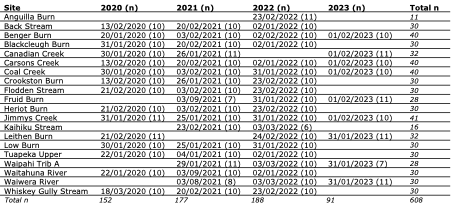
<figcaption>Figure 7: Catch date and the total number (n) of juvenile brown trout sampled from each location each year.</figcaption>
</figure>

<figure id="fig-reference-material">
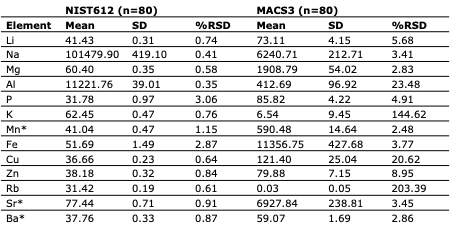
<figcaption>Figure 8: Mean (g/g), standard deviation, and relative standard deviation of the reference materials NIST612 and MACS3. * The three selected elements.</figcaption>
</figure>

``` python
vars_other <- c(
  "meanLi7",
  "meanNa23",
  "meanMg24",
  "meanAl27",
  "meanP31",
  "meanK39",
  "meanFe57",
  "meanCu65",
  "meanZn66",
  "meanRb85"
)

# make long format of the other elements
df_mean_juv_long_other <- df_mean_juv_clean %>%
  dplyr::select(Slide_code, Year, Site, dplyr::all_of(vars_other)) %>%
  tidyr::pivot_longer(
    cols = dplyr::all_of(vars_other),
    names_to = "Variable",
    values_to = "Value"
  ) %>%
  dplyr::mutate(Variable = factor(Variable, levels = vars_other))

# Calculate the mean for each variable
mean_values_other <- df_mean_juv_long_other %>%
  group_by(Variable) %>%
  summarise(mean_values_other = mean(Value, na.rm = TRUE))

# Create the plot
other_elements <- ggplot(
  df_mean_juv_long_other,
  aes(Site, Value, fill = as.factor(Year))
) + #
  geom_boxplot(size = 0.2, outlier.shape = 16, outlier.size = .5) +
  geom_hline(
    data = mean_values_other,
    aes(yintercept = mean_values_other),
    linetype = 2,
  ) + # Mean line for each variable
  facet_wrap(~Variable, scales = "free_y", ncol = 2) + # Facet by the variable names
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    strip.text.x = element_text(),
    labs(fill = "Year")
  ) +
  guides(fill = guide_legend(title = "Year"))

ggsave(
  other_elements,
  file = file.path(out_dir, "fig-other-elements.png"),
  width = 10,
  height = 10,
  dpi = 600
)

other_elements
```

<figure id="fig-other-elements">
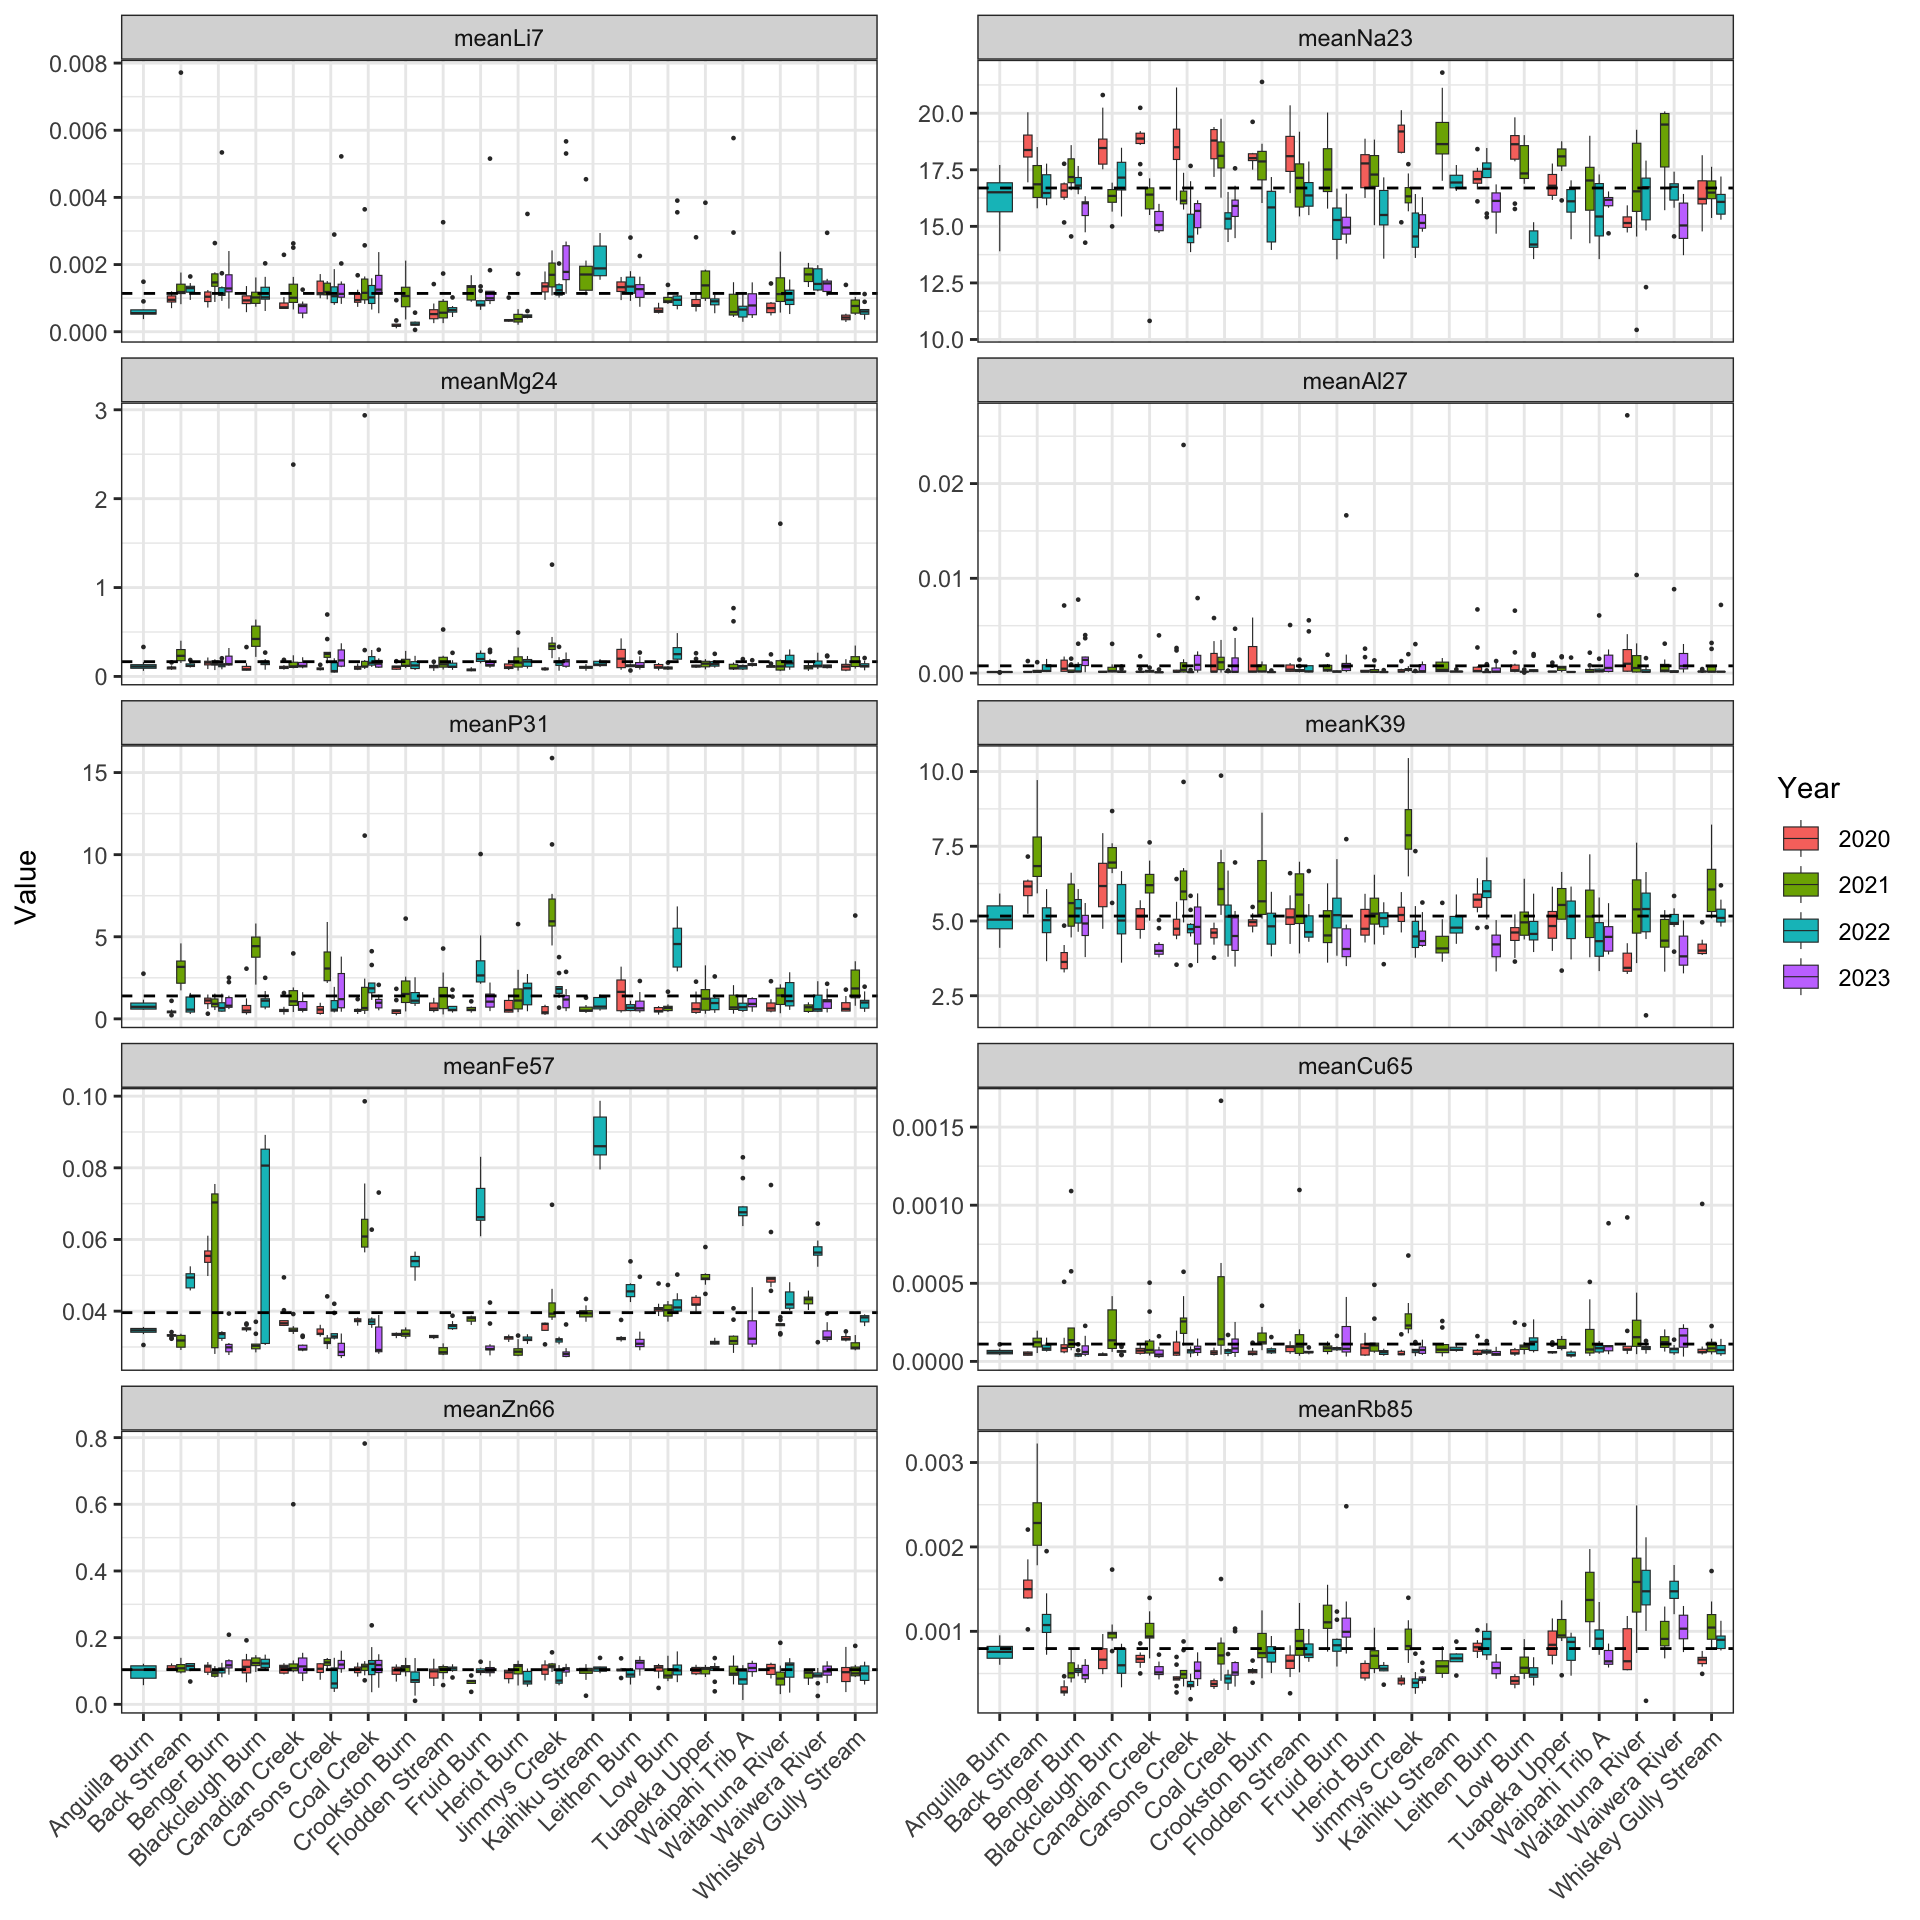
<figcaption>Figure 9: Boxplots showing the mean of the elements in element:Ca ratio in mmol/mol. Divided over the 20 sites and years (colours). The mean of all sites (dashed line).</figcaption>
</figure>

``` python
sites <- list(
  "Waiwera River" = filter(df_mean_juv_clean, Site == "Waiwera River"),
  "Waitahuna River" = filter(df_mean_juv_clean, Site == "Waitahuna River"),
  "Fruid Burn" = filter(df_mean_juv_clean, Site == "Fruid Burn")
)

elements <- c("meanMn55", "meanSr88", "meanBa138")

results <- list()

for (site_name in names(sites)) {
  df_site <- sites[[site_name]]
  df_site$Year <- as.factor(df_site$Year)

  for (elem in elements) {
    formula <- as.formula(paste(elem, "~ Year"))
    anova_res <- aov(formula, data = df_site)
    sm <- summary(anova_res)
    f_val <- round(sm[[1]]$`F value`[1], 3)
    p_val <- sm[[1]]$`Pr(>F)`[1]

    # Significance stars
    sig <- dplyr::case_when(
      p_val < 0.001 ~ "***",
      p_val < 0.01 ~ "**",
      p_val < 0.05 ~ "*",
      TRUE ~ ""
    )

    # Always return a character string
    p_fmt <- as.character(
      ifelse(
        p_val < 0.0001,
        formatC(p_val, format = "e", digits = 2),
        as.character(round(p_val, 3))
      )
    )

    # Tukey HSD
    tukey <- TukeyHSD(anova_res)
    tukey_df <- as.data.frame(tukey$Year)
    tukey_df$comparison <- rownames(tukey_df)

    tukey_str <- if (p_val < 0.05) {
      paste(
        apply(tukey_df, 1, function(row) {
          comp <- row["comparison"]
          diff <- round(as.numeric(row["diff"]), 5)
          p_t <- round(as.numeric(row["p adj"]), 4)
          paste0(comp, ": ", diff, " (p=", p_t, ")")
        }),
        collapse = "\n"
      )
    } else {
      ""
    }

    results[[length(results) + 1]] <- data.frame(
      Site = site_name,
      Element = elem,
      F_value = f_val,
      Pr_F = p_fmt,
      Significance = sig,
      Tukey_HSD = tukey_str,
      stringsAsFactors = FALSE
    )
  }
}


tbl_temporal <- bind_rows(results)

# Keep site name only on first row per site
tbl_temporal <- tbl_temporal |>
  group_by(Site) |>
  mutate(Site = ifelse(row_number() == 1, Site, "")) |>
  ungroup()

colnames(tbl_temporal) <- c(
  "Site",
  "Element",
  "F value",
  "Pr(>F)",
  "Significance",
  "Tukey HSD Results"
)

knitr::kable(tbl_temporal)
#| label: tbl-temporal
#| include: true
#| echo: false
#| tbl-cap: "Output of ANOVA and Tukey's HSD test of the three sites that have been sampled in August and September instead of January till March in 2021."

# Re-run the ANOVAs for Waiwera specifically
waiwera_data <- filter(df_mean_juv_clean, Site == "Waiwera River") |>
  mutate(Year = as.factor(Year))

fruid_data <- filter(df_mean_juv_clean, Site == "Fruid Burn") |>
  mutate(Year = as.factor(Year))

tukey_waiwera_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = waiwera_data))

tukey_fruid_mn <- TukeyHSD(aov(meanMn55 ~ Year, data = fruid_data))
tukey_fruid_sr <- TukeyHSD(aov(meanSr88 ~ Year, data = fruid_data))
tukey_fruid_ba <- TukeyHSD(aov(meanBa138 ~ Year, data = fruid_data))

# Extract p-values
p_waiwera_mn_2022_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2022-2021", "p adj"],
  4
)
p_waiwera_mn_2023_2022 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2022", "p adj"],
  4
)
p_waiwera_mn_2023_2021 <- round(
  as.data.frame(tukey_waiwera_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_mn_2022_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2022-2021", "p adj"],
  4
)
p_fruid_mn_2023_2022 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2022", "p adj"],
  4
)
p_fruid_mn_2023_2021 <- round(
  as.data.frame(tukey_fruid_mn$Year)["2023-2021", "p adj"],
  4
)

p_fruid_sr_2022_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2022-2021", "p adj"],
  4
)
p_fruid_sr_2023_2022 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2022", "p adj"],
  4
)
p_fruid_sr_2023_2021 <- round(
  as.data.frame(tukey_fruid_sr$Year)["2023-2021", "p adj"],
  4
)

p_fruid_ba_2022_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2022-2021", "p adj"],
  4
)
p_fruid_ba_2023_2022 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2022", "p adj"],
  4
)
p_fruid_ba_2023_2021 <- round(
  as.data.frame(tukey_fruid_ba$Year)["2023-2021", "p adj"],
  4
)


saveRDS(
  list(
    accuracy_lda = accuracy_lda,
    accuracy_rf = accuracy_rf,
    p_waiwera_mn_2022_2021 = p_waiwera_mn_2022_2021,
    p_mn_2015_2022 = p_mn_2015_2022,
    p_ba_2015_2022 = p_ba_2015_2022,
    p_ba_2015_2021 = p_ba_2015_2021,
    p_ba_2023_2021 = p_ba_2023_2021,
    p_ba_2023_2022 = p_ba_2023_2022,
    accuracy_Svirgsden_rf = accuracy_Svirgsden_rf,
    accuracy_Svirgsden_lda = accuracy_Svirgsden_lda,
    accuracy_lda_nnca = accuracy_lda_nnca,
    accuracy_rf_nnca = accuracy_rf_nnca
  ),
  "data/derived/inline_values.rds"
)
```

| Site | Element | F value | Pr(\>F) | Significance | Tukey HSD Results |
|:-------|:--------|-------|:-------|:----------|:-----------------------------|
| Waiwera River | meanMn55 | 7.745 | 0.002 | \*\* | 2022-2021: -0.00474 (p=0.0036) |

Table 6: Output of ANOVA and Tukey’s HSD test of the three sites that have been sampled in August and September instead of January till March in 2021.